# Joint MCMC Analysis — DIB 15272 / 15672, C2v / Cs
Loads any backend produced by `run_emcee_asym_both.py`, infers all settings
from the filename, redoes the full convergence analysis, makes the corner plot,
and draws 10 posterior-sample profile overlays.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.gridspec as gridspec
import corner, h5py, os, glob, re, io, subprocess, tempfile
import emcee
from scipy.stats import gaussian_kde, ks_2samp
from scipy.ndimage import gaussian_filter
from scipy.interpolate import interp1d
from scipy.signal import fftconvolve
from IPython.display import display, Image
import warnings
import os.path as osp
warnings.filterwarnings('ignore')
from IPython.display import display, HTML
display(HTML("<style>.container { width:90% !important; }</style>"))

import sys
sys.path.insert(0, os.path.expanduser('~/DIB'))
from MCMC_convergence_tests import detect_multimodal, ks_stability_test, compute_rhat, format_diagnostics

# ── Matplotlib style ──────────────────────────────────────────────────────────
mpl.rcParams.update(mpl.rcParamsDefault)
plt.rcParams['figure.facecolor'] = 'white'
plt.rc('text', usetex=False)
plt.rc('font', family='serif', size=12)
plt.rc('axes', linewidth=1.5)
plt.rc('xtick', labelsize=11, direction='in', top=True)
plt.rc('ytick', labelsize=11, direction='in', right=True)
plt.rc('xtick.minor', visible=True)
plt.rc('ytick.minor', visible=True)
plt.rc('xtick.major', size=6, pad=4)
plt.rc('xtick.minor', size=3)
plt.rc('ytick.major', size=6)
plt.rc('ytick.minor', size=3)
plt.rc('legend', fontsize=10)
import datetime
import pandas as pd
from scipy.stats import chi2 as chi2_dist


## 15  PGOPHER Setup
Define spectrum generation functions (mirroring `run_emcee_asym_both.py`).

In [36]:
PGO_BINARY = os.path.expanduser('~/DIB/./pgo')
pgo_available = os.path.isfile(PGO_BINARY)
if not pgo_available:
    print('⚠  pgo binary not found — profile plot cells will be skipped.')

data_wavelength = np.linspace(15272.27178113337 - 6.5, 15272.27178113337+6.5, 2000)
CENTRAL_INVCM_BASE = 1e8 / 15272.27178113337
symmetry = inferred_sym = 'Cs'
PGO_TEMPLATES = {
    ('C2v', '15272'):      os.path.expanduser('~/DIB/pgo_files/asym_top_15272_C2v.pgo'),
    ('Cs',  '15272', 'a'): os.path.expanduser('~/DIB/pgo_files/asym_top_15272_Cs_a.pgo'),
    ('Cs',  '15272', 'b'): os.path.expanduser('~/DIB/pgo_files/asym_top_15272_Cs_b.pgo')
}

TEMP_DIR = tempfile.mkdtemp(prefix='dib_analysis_pgo_')
print(f'PGOPHER temp dir: {TEMP_DIR}')

def _fname_base(T, A, B, C, fA, fB, fC, lorentz=0.01, gaussian = 0.3, axis='b', co=0.0):
    return (f'T{T:.4f}_A{A:.7f}_B{B:.7f}_C{C:.7f}_'
            f'FA{fA:.5f}_FB{fB:.5f}_FC{fC:.5f}_ax{axis}_lt{lorentz:.3f}_gauss{gaussian:.3f}_off{co:.2f}')

def _run_pgo(T, A, B, C, fA, fB, fC, lorentz, gaussian, axis, center_offset, template_key):
    """Template-substitute and run pgo; return path to spectrum text file."""
    PGO_TEMPLATE = PGO_TEMPLATES[template_key]
    A_g, B_g, C_g = A, B, C
    A_e, B_e, C_e = A*fA, B*fB, C*fC
    center = CENTRAL_INVCM_BASE + center_offset
    base   = _fname_base(T, A, B, C, fA, fB, fC, lorentz, gaussian, axis, center_offset)
    pgo_file  = os.path.join(TEMP_DIR, f'tmp_{base}.pgo')
    spec_file = os.path.join(TEMP_DIR, f'spc_{base}.txt')

    # Build awk substitution script
    # The awk structure differs slightly between C2v/15272, C2v/15672, and Cs.
    # We use the same approach as run_emcee_asym_both.py.
    sym = inferred_sym
    dib = inferred_dib

    if sym == 'C2v' and dib == '15272':
        awk_script = f"""
awk -v temp="{T}" -v A_ground="{A_g}" -v B_ground="{B_g}" -v C_ground="{C_g}" \\
    -v A_excited="{A_e}" -v B_excited="{B_e}" -v C_excited="{C_e}" \\
    -v axis="{axis}" -v lorentz_width="{lorentz}" -v gaussian_width="{gaussian}"'
BEGIN {{ in_ground=0; in_excited=0; }}
/<AsymmetricTop Name="v=0"/ {{ in_ground=1 }}
/<AsymmetricTop Name="v=1"/ {{ in_excited=1 }}
/<\/AsymmetricTop>/ {{ in_ground=0; in_excited=0 }}
in_ground  && /<Parameter Name="A" Value=/ {{ sub(/Value="[0-9.eE+-]+"/, "Value=\\"" A_ground "\\"") }}
in_ground  && /<Parameter Name="B" Value=/ {{ sub(/Value="[0-9.eE+-]+"/, "Value=\\"" B_ground "\\"") }}
in_ground  && /<Parameter Name="C" Value=/ {{ sub(/Value="[0-9.eE+-]+"/, "Value=\\"" C_ground "\\"") }}
in_excited && /<Parameter Name="A" Value=/ {{ sub(/Value="[0-9.eE+-]+"/, "Value=\\"" A_excited "\\"") }}
in_excited && /<Parameter Name="B" Value=/ {{ sub(/Value="[0-9.eE+-]+"/, "Value=\\"" B_excited "\\"") }}
in_excited && /<Parameter Name="C" Value=/ {{ sub(/Value="[0-9.eE+-]+"/, "Value=\\"" C_excited "\\"") }}
/<CartesianTransitionMoment Bra="v=1" Ket="v=0"/ {{ sub(/Axis="[^"]+"/, "Axis=\\"" axis "\\"") }}
/<Parameter Name="Temperature" Value=/ {{ sub(/Value="[0-9.eE+-]+"/, "Value=\\"" temp "\\"") }}
/<Parameter Name="Lorentzian" Value=/ {{ sub(/Value="[0-9.eE+-]+"/, "Value=\\"" lorentz_width "\\"") }}
/<Parameter Name="Gaussian" Value="/ {{ sub(/Value="[0-9.eE+-]+"/, "Value=\\"" gaussian_width "\\"") }}
{{ print }}
' {PGO_TEMPLATE} > {pgo_file}
"""
    else:  # C2v/15672 or any Cs — both use Origin + manifest names
        awk_script = f"""
awk -v temp="{T}" -v A_ground="{A_g}" -v B_ground="{B_g}" -v C_ground="{C_g}" \\
    -v A_excited="{A_e}" -v B_excited="{B_e}" -v C_excited="{C_e}" \\
    -v lorentz_width="{lorentz}" -v gaussian_width="{gaussian}" -v center="{center}" '
BEGIN {{ inside_ground=0; inside_excited=0; }}
/<Parameter Name="Temperature" Value="/ {{ sub(/Value="[0-9.eE+-]+"/, "Value=\\"" temp "\\"") }}
/<AsymmetricManifold Name="Ground"/ {{ inside_ground=1 }}
/<AsymmetricManifold Name="Excited"/ {{ inside_excited=1 }}
/<\/AsymmetricManifold>/ {{ inside_ground=0; inside_excited=0 }}
inside_ground  && /<Parameter Name="A" Value="/ {{ sub(/Value="[0-9.eE+-]+"/, "Value=\\"" A_ground "\\"") }}
inside_ground  && /<Parameter Name="B" Value="/ {{ sub(/Value="[0-9.eE+-]+"/, "Value=\\"" B_ground "\\"") }}
inside_ground  && /<Parameter Name="C" Value="/ {{ sub(/Value="[0-9.eE+-]+"/, "Value=\\"" C_ground "\\"") }}
inside_excited && /<Parameter Name="Origin" Value="/ {{ sub(/Value="[0-9.eE+-]+"/, "Value=\\"" center "\\"") }}
inside_excited && /<Parameter Name="A" Value="/ {{ sub(/Value="[0-9.eE+-]+"/, "Value=\\"" A_excited "\\"") }}
inside_excited && /<Parameter Name="B" Value="/ {{ sub(/Value="[0-9.eE+-]+"/, "Value=\\"" B_excited "\\"") }}
inside_excited && /<Parameter Name="C" Value="/ {{ sub(/Value="[0-9.eE+-]+"/, "Value=\\"" C_excited "\\"") }}
/<Parameter Name="Lorentzian" Value="/ {{ sub(/Value="[0-9.eE+-]+"/, "Value=\\"" lorentz_width "\\"") }}
/<Parameter Name="Gaussian" Value="/ {{ sub(/Value="[0-9.eE+-]+"/, "Value=\\"" gaussian_width "\\"") }}
{{ print }}
' {PGO_TEMPLATE} > {pgo_file}
"""

    subprocess.run(awk_script, shell=True, check=True, executable='/bin/bash')
    subprocess.run([PGO_BINARY, '--plot', pgo_file, spec_file],
                   check=True, stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)
    return spec_file


def get_pgopher_spectrum(spec_file, center_offset=0.0, dlam=0.01, window=8):
    """Load a PGOPHER spectrum txt and interpolate to data_wavelength grid,
    applying the analytical 3-Gaussian LSF if needed."""
    inv_cm, flux = np.loadtxt(spec_file).T
    wav_pgo = 1e8 / inv_cm

    out_i  = interp1d(wav_pgo, flux, bounds_error=False, fill_value=np.nan)

    return out_i(data_wavelength)


def unpack_params(params):
    """Return (T, A, B, C, fA, fB, fC, lorentz, center_offset) from a flat param vector."""
    if B_not_equal_C:
        if has_center_offset:
            T, A, B, C, fA, fB, fC, lt, sig, co = params
        else:
            T, A, B, C, fA, fB, fC, lt, sig = params; co = 0.0
    else:
        if has_center_offset:
            T, A, C, fA, fC, lt, sig, co = params
        else:
            T, A, C, fA, fC, lt, sig = params; co = 0.0
        if inferred_sym == 'C2v':
            B, fB = A, fA
        else:  # Cs
            B, fB = C, fC
    return T, A, B, C, fA, fB, fC, lt, sig, co


def generate_spectra(params):
    """Run PGOPHER for a param vector; return (model_flux, model_flux_dT) on data_wavelength."""
    T, A, B, C, fA, fB, fC, lt, sig, co = unpack_params(params)
    if inferred_sym == 'C2v':
        tkey = ('C2v', inferred_dib)
        sf      = _run_pgo(T,      A, B, C, fA, fB, fC, lt, sig, 'a', co, tkey)
        sf_dT   = _run_pgo(T+0.05, A, B, C, fA, fB, fC, lt, sig, 'a', co, tkey)
        mf    = get_pgopher_spectrum(sf,    co)
        mf_dT = get_pgopher_spectrum(sf_dT, co)
        return {'C2v': (mf, mf_dT)}
    else:  # Cs — two axes
        results = {}
        for axis in ('a', 'b'):
            tkey  = ('Cs', inferred_dib, axis)
            sf    = _run_pgo(T,      A, B, C, fA, fB, fC, lt, sig, axis, co, tkey)
            sf_dT = _run_pgo(T+0.05, A, B, C, fA, fB, fC, lt, sig, axis, co, tkey)
            results[axis] = (get_pgopher_spectrum(sf, co),
                             get_pgopher_spectrum(sf_dT, co))
        return results


def reconstruct_model(spectra_dict, blob_row):
    """From PGOPHER spectra + blob scalars (or rerun), return (model_dib, model_dT) on the
    cropped wavelength grid [c_crop:-c_crop]."""
    c, gf = c_crop, gf_sigma

    if inferred_sym == 'C2v':
        mf, mf_dT = spectra_dict['C2v']
        spec    = gaussian_filter(mf[c:-c],    gf)
        spec_dT = gaussian_filter(mf_dT[c:-c], gf) - spec

        if rerun_coefficients:
            meas      = data_flux[c:-c]
            meas_dT   = data_flux_dT[c:-c]
            M         = np.vstack([spec, np.ones_like(spec)]).T
            gamma, offset = np.linalg.lstsq(M, meas, rcond=None)[0]
            M_dT      = np.vstack([spec, spec_dT, np.ones_like(spec)]).T
            alpha_dT, beta_dT, offset_dT = np.linalg.lstsq(M_dT, meas_dT, rcond=None)[0]
        else:
            gamma, _, offset, alpha_dT, beta_dT, offset_dT = blob_row[:6]

        model_dib = gamma * spec + offset
        model_dT  = alpha_dT * spec + beta_dT * spec_dT + offset_dT
        return model_dib, model_dT

    else:  # Cs
        mf_b,  mf_dT_b  = spectra_dict['a']  # a-axis = b-type
        mf_c,  mf_dT_c  = spectra_dict['b']  # b-axis = c-type
        spec_b    = gaussian_filter(mf_b[c:-c],    gf)
        spec_c    = gaussian_filter(mf_c[c:-c],    gf)
        spec_dT_b = gaussian_filter(mf_dT_b[c:-c], gf) - spec_b
        spec_dT_c = gaussian_filter(mf_dT_c[c:-c], gf) - spec_c

        if rerun_coefficients:
            meas    = data_flux[c:-c]
            meas_dT = data_flux_dT[c:-c]
            M       = np.vstack([spec_b, spec_c, np.ones_like(spec_b)]).T
            b_frac, c_frac, offset = np.linalg.lstsq(M, meas, rcond=None)[0]
            ratio   = b_frac / (c_frac + 1e-10)
            base    = spec_b + ratio * spec_c
            delta_b = spec_dT_bp
            delta_c = spec_dT_c
            M_dT    = np.vstack([base, delta_b + ratio * delta_c, np.ones_like(base)]).T
            alpha_dT, beta_dT, offset_dT = np.linalg.lstsq(M_dT, meas_dT, rcond=None)[0]
            base_frac_dT = 0.0
            model_dib = b_frac * spec_b + c_frac * spec_c + offset
            model_dT  = alpha_dT * base + beta_dT * (delta_b + ratio * delta_c) + offset_dT
        elif n_blobs == 7:  # use_scalar_prior=True path
            b_frac, c_frac, offset, base_frac_dT, b_frac_dT, c_frac_dT, offset_dT = blob_row[:7]
            ratio     = b_frac / (c_frac + 1e-10)
            base      = spec_b + ratio * spec_c
            model_dib = b_frac * spec_b + c_frac * spec_c + offset
            model_dT  = (base_frac_dT * base +
                         b_frac_dT * spec_dT_b + c_frac_dT * spec_dT_c + offset_dT)
        else:  # 6-blob nonlinear path
            gamma, ratio_bc, offset_spec, alpha_dT, beta_dT, offset_dT = blob_row[:6]
            base      = spec_b + ratio_bc * spec_c
            delta     = spec_dT_b + ratio_bc * spec_dT_c
            model_dib = gamma * base + offset_spec
            model_dT  = alpha_dT * base + beta_dT * delta + offset_dT

        return model_dib, model_dT, 
    
def return_model(spectra_dict, blob_row):
    """From PGOPHER spectra + blob scalars (or rerun), return (model_dib, model_dT) on the
    cropped wavelength grid [c_crop:-c_crop]."""
    c, gf = c_crop, gf_sigma

    if inferred_sym == 'C2v':
        mf, mf_dT = spectra_dict['C2v']
        return mf, mf_dT

    else:  # Cs
        mf_b,  mf_dT_b  = spectra_dict['a']  # a-axis = b-type
        mf_c,  mf_dT_c  = spectra_dict['b']  # b-axis = c-type

        return (mf_b, mf_c), (mf_dT_b, mf_dT_c)

print('PGOPHER helper functions defined.')
print(f'pgo binary: {"found" if pgo_available else "NOT FOUND — profile plot will be skipped"}')

PGOPHER temp dir: /tmp/dib_analysis_pgo_cu6fmbkw
PGOPHER helper functions defined.
pgo binary: found


## 16  Draw Posterior Samples & Generate Model Spectra

In [38]:
models_dib = []
models_dT  = []
T, A, B, C, fA, fB, fC, lt, sig = [10, 0.01, 0.001, 0.001, 0.99, 0.99, 0.99, 0.3, 0.3]
ratio_bc, alpha_dT = 1, 1
B_not_equal_C = True
has_center_offset = True
inferred_dib = '15272'
inferred_sym = 'Cs'
c_crop, gf_sigma = 1, 0
rerun_coefficients = False

params     = [T, A, B, C, fA, fB, fC, lt, sig, 0] #offset always zero
blob_row   = [1, ratio_bc, 0, alpha_dT, 1, 0]
n_blobs = len(blob_row)

try:
    spectra    = generate_spectra(params)
    mdib, mdT  = return_model(spectra, blob_row)
    print(mdib, mdT)
    models_dib.append(mdib)
    models_dT.append(mdT)
except Exception as e:
    print(f'FAILED: {e}')
    models_dib.append(None)
    models_dT.append(None)

models_dib = [m for m in models_dib if m is not None]
models_dT  = [m for m in models_dT  if m is not None]

(array([       nan,        nan,        nan, ..., 0.00215052, 0.00214599,
       0.00214148]), array([       nan,        nan,        nan, ..., 0.00228415, 0.00227888,
       0.00227365])) (array([       nan,        nan,        nan, ..., 0.00214974, 0.00214521,
       0.0021407 ]), array([       nan,        nan,        nan, ..., 0.00228444, 0.00227917,
       0.00227392]))


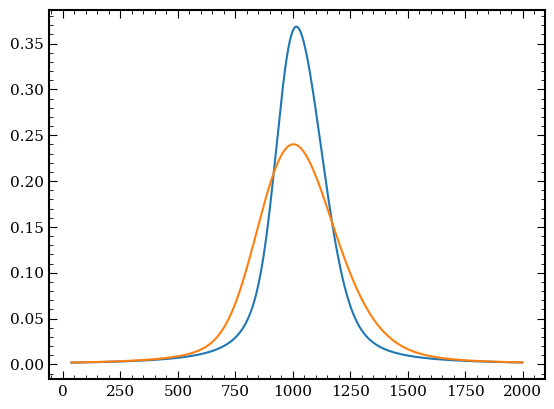

In [39]:
plt.plot(mdib[0])
plt.plot(mdib[1])

## 18  Profile Figure — χ², Errorbars, Two Error Versions

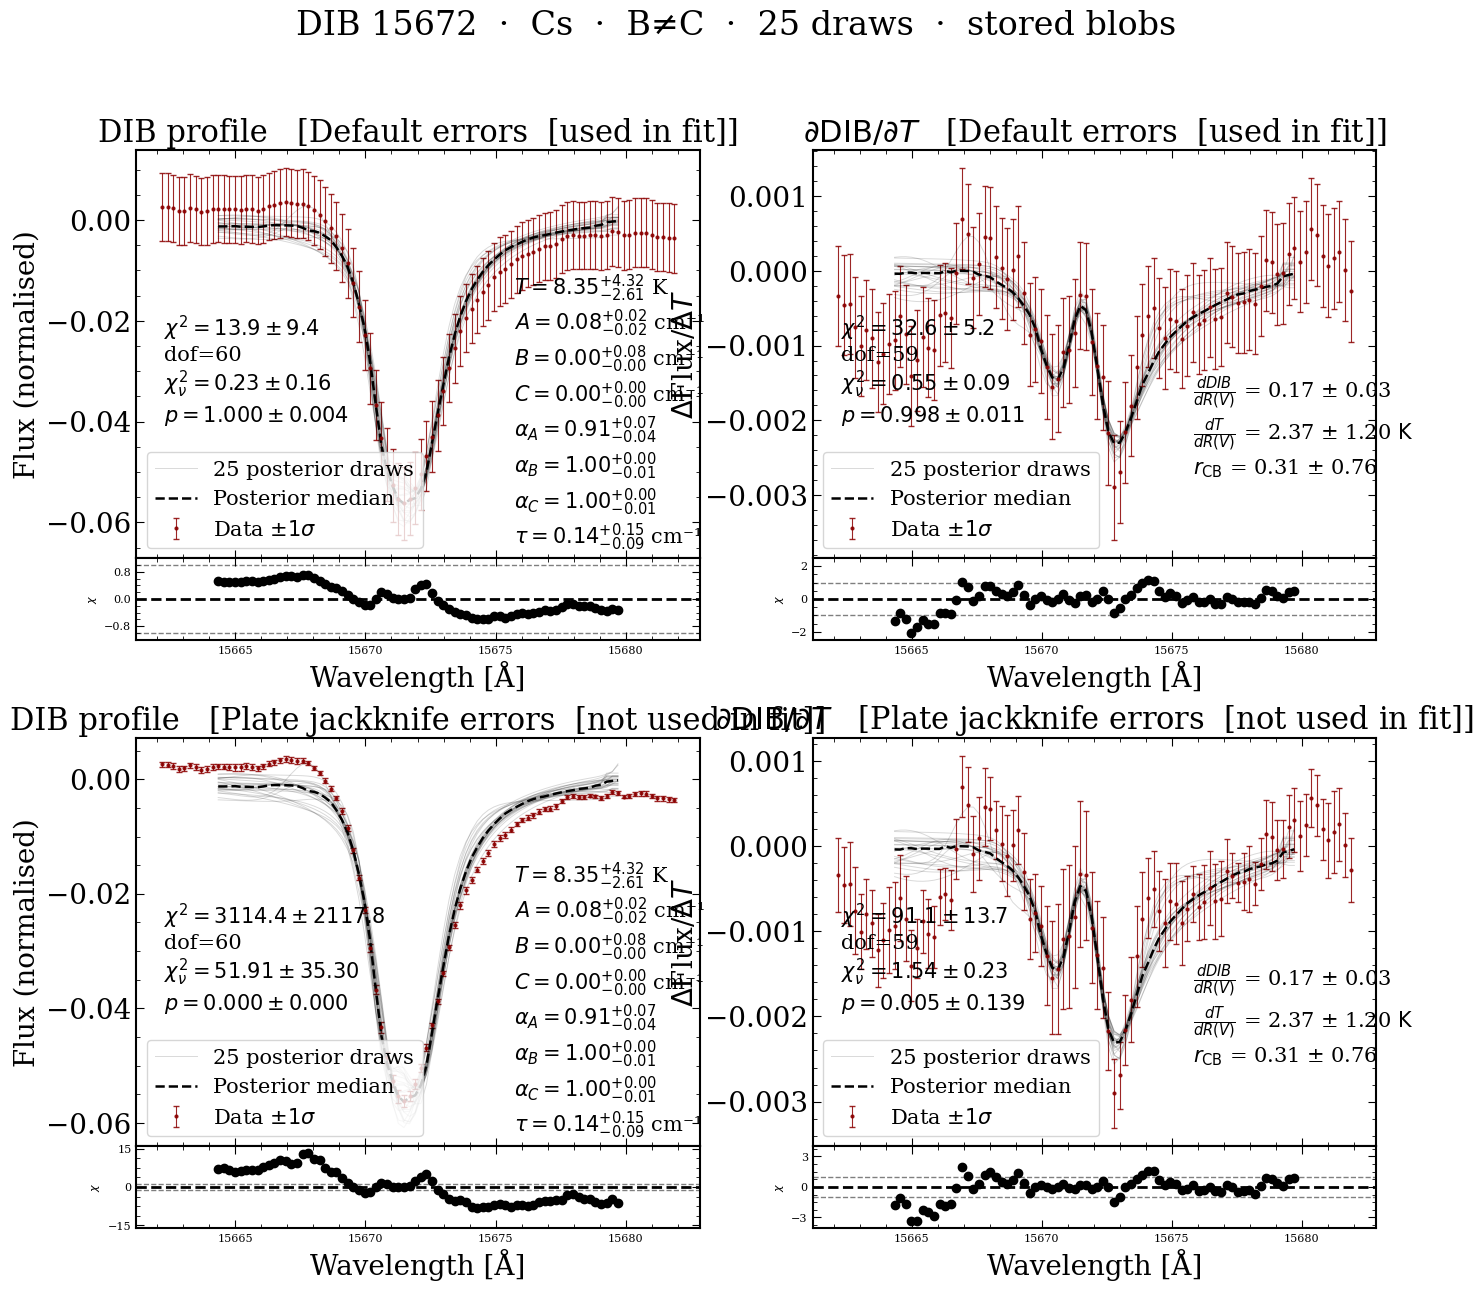

Cleaned up temp dir: /tmp/dib_analysis_pgo_fn2zuk0t


In [268]:
import re
from matplotlib.gridspec import GridSpec, GridSpecFromSubplotSpec

if not pgo_available or not models_dib:
    print('No model spectra available — skipping profile figure.')
else:
    c          = c_crop
    wav_full   = data_wavelength
    wav_centre = 1e8 / CENTRAL_INVCM_BASE

    wav_crop   = data_wavelength[c:-c]

    dat_dib = data_flux
    dat_dT  = data_flux_dT

    # ── Error versions ───────────────────────────────────────────────────────
    err_type_str = 'Plate' if use_plate_errs else ('Old' if use_old_errs else 'Default')
    err_dib_cur  = noise_std
    err_dT_cur   = noise_std_dT

    err_sets = [
        (err_dib_cur, err_dT_cur, f'{err_type_str} errors  [used in fit]', True),
    ]
    try:
        with h5py.File(PLATE_ERR_MAP[inferred_dib], 'r') as pf:
            _pe_dib = (np.sqrt(pf['var'][:, 0]) * fudge)
            _pe_dT  = (np.sqrt(pf['var'][:, 1]) * fudge)
        if not use_plate_errs:
            err_sets.append((_pe_dib, _pe_dT, 'Plate jackknife errors  [not used in fit]', False))
    except Exception:
        pass
    if use_plate_errs:
        try:
            with h5py.File(DATA_FILE_MAP[inferred_dib], 'r') as df:
                _df_dib = (np.sqrt(df['var'][:, 0]) * fudge)
                _df_dT  = (np.sqrt(df['var'][:, 1]) * fudge)
            err_sets.append((_df_dib, _df_dT, 'Default errors  [not used in fit]', False))
        except Exception:
            pass

    # ── Median models ────────────────────────────────────────────────────────
    med_dib = np.median(np.array(models_dib), axis=0)
    med_dT  = np.median(np.array(models_dT),  axis=0)

    # ── DoF per panel ────────────────────────────────────────────────────────
    if inferred_sym == 'C2v':
        n_spec_sc, n_dT_sc = 2, 3
    elif n_blobs == 7:
        n_spec_sc, n_dT_sc = 3, 4
    else:
        n_spec_sc, n_dT_sc = 3, 4

    def chi2_stats(data, models_list, err, n_scalar, extra_trunc = 0):
        cl = c+extra_trunc
        data_c = data[cl:-cl]
        err_c  = err[cl:-cl]
        dof    = len(data_c) - ndim - n_scalar
        if extra_trunc!=0:
            cv_samps = np.array([np.sum(((data_c - m[extra_trunc:-extra_trunc]) / err_c)**2) for m in models_list])
        else:
            cv_samps = np.array([np.sum(((data_c - m) / err_c)**2) for m in models_list])
            
        cr_samps = cv_samps / dof if dof > 0 else np.full_like(cv_samps, np.nan)
        pv_samps = np.array([float(chi2_dist.sf(cv, dof)) for cv in cv_samps]) if dof > 0 \
                   else np.full_like(cv_samps, np.nan)
        cv  = float(np.median(cv_samps));  se_cv = float(np.std(cv_samps))
        cr  = float(np.median(cr_samps));  se_cr = float(np.std(cr_samps))
        pv  = float(np.median(pv_samps));  se_pv = float(np.std(pv_samps))
        return cv, cr, pv, dof, se_cv, se_cr, se_pv

    # ── Derived quantities ───────────────────────────────────────────────────
    if inferred_sym == 'C2v':
        _gamma    = flat_blobs[:, 0]
        _alpha_dT = flat_blobs[:, 3]
        _beta_dT  = flat_blobs[:, 4]
        safe_g      = np.where(np.abs(_gamma) > 1e-10, _gamma, np.nan)
        alpha_ratio = _alpha_dT / safe_g / cRV
        beta_ratio  = deltaT / cRV * _beta_dT / safe_g
        derived = np.column_stack([alpha_ratio, beta_ratio])
        derived_labels = [r'$\frac{dDIB}{dR(V)}$', r'$\frac{dT}{dR(V)}$']
        derived_units  = ['', r'$\mathrm{K}$']

    if inferred_sym == 'Cs':
        _gamma    = flat_blobs[:, 0]
        ratio_bc  = flat_blobs[:, 1]
        _alpha_dT = flat_blobs[:, 3]
        _beta_dT  = flat_blobs[:, 4]
        safe_g      = np.where(np.abs(_gamma) > 1e-10, _gamma, np.nan)
        alpha_ratio = _alpha_dT / safe_g / cRV
        beta_ratio  = deltaT / cRV * _beta_dT / safe_g
        derived = np.column_stack([alpha_ratio, beta_ratio, ratio_bc])
        derived_labels = [r'$\frac{dDIB}{dR(V)}$', r'$\frac{dT}{dR(V)}$', r'$r_\mathrm{CB}$']
        derived_units  = ['', r'$\mathrm{K}$', '']

    variation_txt = "\n".join(
        f"{label} = {np.median(derived[:, i]):.2f} ± "
        f"{np.diff(np.percentile(derived[:, i], [16, 84]))[0] / 2:.2f} {derived_units[i]}"
        for i, label in enumerate(derived_labels)
    )

    def parse_label(label):
        label = label.strip()
        unit_match = re.search(r'\[([^\]]+)\]', label)
        unit = unit_match.group(1) if unit_match else ''
        name = re.sub(r'\s*\[[^\]]+\]', '', label).strip().strip('$')
        return name, unit

    param_txt = "\n".join(
        r"${name} = {med:.2f}^{{+{up:.2f}}}_{{-{lo:.2f}}}$ {unit}".format(
            name=name,
            med=np.median(flat_samples[:, i]),
            up=np.percentile(flat_samples[:, i], 84) - np.median(flat_samples[:, i]),
            lo=np.median(flat_samples[:, i]) - np.percentile(flat_samples[:, i], 16),
            unit=unit,
        )
        for i, label in enumerate(labels[:-1])
        for name, unit in [parse_label(label)]
    )

    # ── Figure layout: each row has 2 columns, each column has main + residual
    DARK_RED = '#8B0000'
    SAMP_COL = 'k'
    MED_COL  = 'k'
    n_rows   = len(err_sets)

    fig18 = plt.figure(figsize=(16, 7 * n_rows), constrained_layout = False)
    outer_gs = GridSpec(n_rows, 2, figure=fig18)

    # Store axes for annotation after loop
    all_ax_main = np.empty((n_rows, 2), dtype=object)
    all_ax_res  = np.empty((n_rows, 2), dtype=object)

    for row, (e_dib, e_dT, err_label, is_fit) in enumerate(err_sets):
        for col, (dat, err, models, med, panel_title, ylabel, n_sc) in enumerate([
            (dat_dib, e_dib, models_dib, med_dib,
             'DIB profile', 'Flux (normalised)', n_spec_sc),
            (dat_dT,  e_dT,  models_dT,  med_dT,
             r'$\partial\mathrm{DIB}/\partial T$', r'$\Delta$Flux/$\Delta T$', n_dT_sc),
        ]):
            # Inner GridSpec: main (5) + residual (1)
            inner_gs = GridSpecFromSubplotSpec(
                2, 1, subplot_spec=outer_gs[row, col],
                height_ratios=[5, 1], hspace=0.0
            )
            ax     = fig18.add_subplot(inner_gs[0])
            ax_res = fig18.add_subplot(inner_gs[1], sharex=ax)
            all_ax_main[row, col] = ax
            all_ax_res[row, col]  = ax_res

            # ── Main panel ───────────────────────────────────────────────────
            ax.errorbar(wav_full, dat, yerr=err,
                        fmt='o', color=DARK_RED, ecolor=DARK_RED,
                        markersize=2, elinewidth=0.8, capsize=2, alpha=0.85,
                        label=r'Data $\pm 1\sigma$')
            for k, m in enumerate(models):
                ax.plot(wav_crop, m, color=SAMP_COL, alpha=0.15, lw=0.7,
                        label=f'{len(models)} posterior draws' if k == 0 else None)
            ax.plot(wav_crop, med, color=MED_COL, lw=1.8, ls='--', label='Posterior median')

            cv, cr, pv, dof, se_cv, se_cr, se_pv = chi2_stats(dat, models, err, n_sc)
            ax.annotate(
                f'$\\chi^2 = {cv:.1f} \\pm {se_cv:.1f}$\n'
                f'dof={dof}\n'
                f'$\\chi^2_\\nu = {cr:.2f} \\pm {se_cr:.2f}$\n'
                f'$p = {pv:.3f} \\pm {se_pv:.3f}$',
                xy=(0.05, 0.6), xycoords='axes fraction',
                va='top', ha='left',
                bbox=dict(boxstyle='round,pad=0.3', fc='white', alpha=0))

            ax.set_ylabel(ylabel)
            ax.set_title(f'{panel_title}   [{err_label}]')
            ax.legend(loc='lower left')
            ax.tick_params(which='both', direction='in', top=True, right=True)
            ax.tick_params(labelbottom=False)

            # ── Residual panel ───────────────────────────────────────────────
            chi_dev = (dat[c:-c] - med) / err[c:-c]
            ax_res.axhline(0, color='k', lw=2, ls='--')
            ax_res.axhline(-1, color='k', alpha = 0.5, lw=1, ls='--')
            ax_res.axhline(1, color='k', alpha = 0.5, lw=1, ls='--')            
            ax_res.plot(wav_crop, chi_dev, 'ko', lw=0.8)
            ax_res.set_ylabel(r'$\chi$', fontsize=8)
            ax_res.set_xlabel(r'Wavelength [Å]')
            
            max_dev = np.max([1, np.max(np.abs(chi_dev))])
            fac = 1.2
            ax_res.set_ylim([-fac*max_dev, fac*max_dev])
            ax_res.tick_params(which='both', direction='in', top=True, right=True, labelsize=8)
            ax_res.yaxis.set_major_locator(plt.MaxNLocator(3, symmetric=True))

        # ── Annotations ──────────────────────────────────────────────────────
        all_ax_main[row, 1].annotate(
            variation_txt,
            xy=(0.675, 0.45), xycoords='axes fraction',
            va='top', ha='left',
            bbox=dict(boxstyle='round,pad=0.3', fc='white', alpha=0))

        all_ax_main[row, 0].annotate(
            param_txt,
            xy=(0.67, 0.7), xycoords='axes fraction',
            va='top', ha='left',
            bbox=dict(boxstyle='round,pad=0.3', fc='white', alpha=0))

    _bnc_str   = 'B≠C' if B_not_equal_C else ('B=C' if inferred_sym == 'C2v' else 'B=C')
    _coeff_str = 'stored blobs' if not rerun_coefficients else 'recomputed coefficients'
    fig18.suptitle(
        f'DIB {inferred_dib}  ·  {inferred_sym}  ·  {_bnc_str}  ·  '
        f'{len(models_dib)} draws  ·  {_coeff_str}',
        fontsize=24
    )
    if save_fig:
        fig18.savefig(os.path.join(FIG_DIR, f'profiles_chi2.pdf'), bbox_inches='tight')
    plt.show()

    import shutil
    shutil.rmtree(TEMP_DIR, ignore_errors=True)
    print(f'Cleaned up temp dir: {TEMP_DIR}')

## 19  PCA Temperature Derivative — 3-Column Comparison
Same molecular parameters as the MCMC fit; linear scalars re-fitted against the PCA dT measurement.

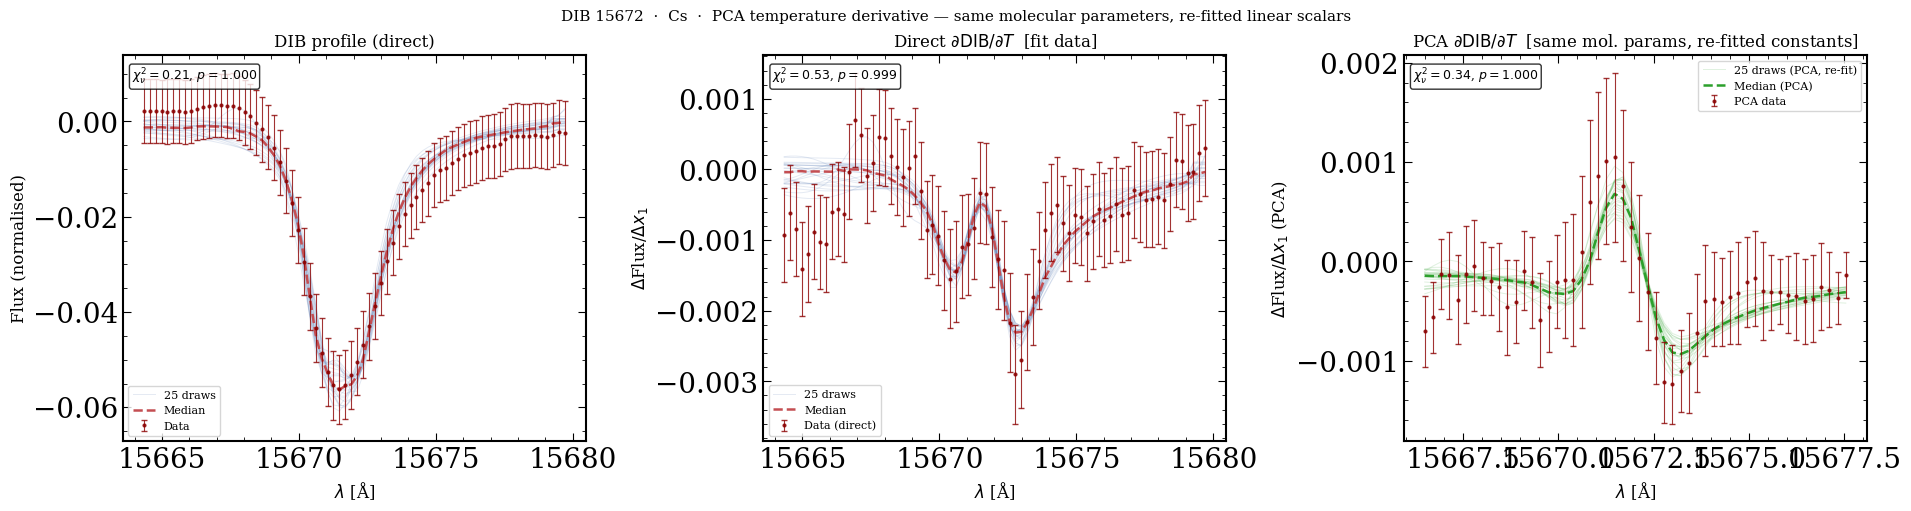

In [269]:
if not pgo_available or not models_dib:
    print('No model spectra available — skipping PCA comparison figure.')
else:
    if dib_band == '15672':
        PCA_FILE     = os.path.expanduser('~/DIB/all_errs/pca_version_15672_narrow.txt')
        OLD_ERR_FILE = os.path.expanduser('~/DIB/all_errs/jackknife_plates_dib_15672.h5')
    if dib_band == '15272':
        PCA_FILE     = os.path.expanduser('~/DIB/all_errs/pca_version_15272_narrow.txt')
        OLD_ERR_FILE = os.path.expanduser('~/DIB/all_errs/jackknife_plates_dib_15272.h5')
    try:
        pca_meas = pd.read_csv(PCA_FILE, sep=r'\s+',
                               names=['wavelength', 'PC1_1', 'PC1_2', 'PC2_1', 'PC2_2'])
        wav_pca  = pca_meas['wavelength'].values
        with h5py.File(OLD_ERR_FILE, 'r') as ef:
            dat_pca_dib = pca_meas['PC1_1'].values
            dat_pca_dT  = pca_meas['PC2_2'].values
            err_pca_dib = np.sqrt(ef['var'][:, 0]) * fudge
            err_pca_dT  = np.sqrt(ef['var'][:, 1]) * fudge
        pca_loaded = True
    except Exception as ex:
        print(f'Could not load PCA data: {ex}')
        pca_loaded = False

    if pca_loaded:
#         c_pca          = 30 #for 15272 old pca_version
        if dib_band == '15672':
            c_pca          = 20
        if dib_band == '15272':
            c_pca          = 10
        wav_pca_crop   = wav_pca[c_pca:-c_pca]
        pca_dT_crop    = dat_pca_dT[c_pca:-c_pca]
        err_pca_dT_c   = err_pca_dT[c_pca:-c_pca]
        err_pca_dib_c  = err_pca_dib[c_pca:-c_pca]

        c        = c_crop
        wav_crop = data_wavelength[c:-c]
        wav_off  = wav_crop - (1e8 / CENTRAL_INVCM_BASE)

        # Scalar DoF
        if inferred_sym == 'C2v':
            n_spec_sc, n_dT_sc = 2, 3
        elif n_blobs == 7:
            n_spec_sc, n_dT_sc = 3, 4
        else:
            n_spec_sc, n_dT_sc = 3, 3

        # ── For each sample: interpolate to PCA grid, re-fit 3 scalars ──────
        models_pca_dT_list = []
        for k in range(len(models_dib)):
            try:
                f_dib = interp1d(wav_crop, models_dib[k], bounds_error=False, fill_value=0.0)
                f_dT  = interp1d(wav_crop, models_dT[k],  bounds_error=False, fill_value=0.0)
                m_d   = f_dib(wav_pca_crop)
                m_t   = f_dT(wav_pca_crop)
                # Fit: a*m_dib + b*m_dT + c_off -> pca_dT
                M   = np.vstack([m_d, m_t, np.ones_like(m_d)]).T
                W   = 1.0 / (err_pca_dT_c + 1e-30)
                c_f, _, _, _ = np.linalg.lstsq(M * W[:, None], pca_dT_crop * W, rcond=None)
                models_pca_dT_list.append(c_f[0]*m_d + c_f[1]*m_t + c_f[2])
            except Exception:
                models_pca_dT_list.append(None)

        models_pca_dT_list = [m for m in models_pca_dT_list if m is not None]
        med_pca_dT = np.median(np.array(models_pca_dT_list), axis=0)

        # chi² helpers (chi2_stats defined in cell 18 — re-define inline if needed)
        def _cs(data, model, err, n_sc):
            resid = (data - model) / err
            cv    = float(np.sum(resid**2))
            dof   = len(data) - ndim - n_sc
            cr    = cv / dof if dof > 0 else float('nan')
            pv    = float(chi2_dist.sf(cv, dof)) if dof > 0 else float('nan')
            return cv, cr, pv, dof

        dat_dib_c = data_flux[c:-c]
        dat_dT_c  = data_flux_dT[c:-c]
        err_dib_c = noise_std[c:-c]
        err_dT_c  = noise_std_dT[c:-c]
        med_dib   = np.median(np.array(models_dib), axis=0)
        med_dT    = np.median(np.array(models_dT),  axis=0)

        cv_dir, cr_dir, pv_dir, dof_dir = _cs(dat_dT_c, med_dT, err_dT_c, n_dT_sc)
        cv_pca, cr_pca, pv_pca, dof_pca = _cs(pca_dT_crop, med_pca_dT, err_pca_dT_c, n_dT_sc + 1)

        # ── Figure ───────────────────────────────────────────────────────────
        fig19, axes19 = plt.subplots(1, 3, figsize=(19, 5), constrained_layout=True)

        DARK_RED   = '#8B0000'
        SAMP_COL   = '#4C72B0'
        MED_COL    = '#C44E52'
        PCA_COL    = '#2CA02C'

        # Col 0: DIB profile
        ax = axes19[0]
        for k, m in enumerate(models_dib):
            ax.plot(wav_crop, m, color=SAMP_COL, alpha=0.15, lw=0.7,
                    label=f'{len(models_dib)} draws' if k == 0 else None)
        ax.plot(wav_crop, med_dib, color=MED_COL, lw=1.8, ls='--', label='Median')
        ax.errorbar(wav_crop, dat_dib_c, yerr=err_dib_c,
                    fmt='o', color=DARK_RED, ecolor=DARK_RED,
                    markersize=2, elinewidth=0.8, capsize=2, alpha=0.8, label='Data')
        cv_s, cr_s, pv_s, dof_s = _cs(dat_dib_c, med_dib, err_dib_c, n_spec_sc)
        ax.annotate(f'$\\chi^2_\\nu = {cr_s:.2f}$, $p = {pv_s:.3f}$',
                    xy=(0.02, 0.97), xycoords='axes fraction', va='top', fontsize=9,
                    bbox=dict(boxstyle='round,pad=0.2', fc='white', alpha=0.8))
        ax.set_title('DIB profile (direct)', fontsize=12)
        ax.set_xlabel(r'$\lambda$ [Å]', fontsize=12)
        ax.set_ylabel('Flux (normalised)', fontsize=12)
        ax.legend(fontsize=8)
        ax.tick_params(which='both', direction='in', top=True, right=True)

        # Col 1: Direct dT (fit data)
        ax = axes19[1]
        for k, m in enumerate(models_dT):
            ax.plot(wav_crop, m, color=SAMP_COL, alpha=0.15, lw=0.7,
                    label=f'{len(models_dT)} draws' if k == 0 else None)
        ax.plot(wav_crop, med_dT, color=MED_COL, lw=1.8, ls='--', label='Median')
        ax.errorbar(wav_crop, dat_dT_c, yerr=err_dT_c,
                    fmt='o', color=DARK_RED, ecolor=DARK_RED,
                    markersize=2, elinewidth=0.8, capsize=2, alpha=0.8, label='Data (direct)')
        ax.annotate(f'$\\chi^2_\\nu = {cr_dir:.2f}$, $p = {pv_dir:.3f}$',
                    xy=(0.02, 0.97), xycoords='axes fraction', va='top', fontsize=9,
                    bbox=dict(boxstyle='round,pad=0.2', fc='white', alpha=0.8))
        ax.set_title(r'Direct $\partial\mathrm{DIB}/\partial T$  [fit data]', fontsize=12)
        ax.set_xlabel(r'$\lambda$ [Å]', fontsize=12)
        ax.set_ylabel(r'$\Delta$Flux/$\Delta x_1$', fontsize=12)
        ax.legend(fontsize=8)
        ax.tick_params(which='both', direction='in', top=True, right=True)

        # Col 2: PCA dT — same molecular params, re-fitted scalars
        ax = axes19[2]
        for k, m in enumerate(models_pca_dT_list):
            ax.plot(wav_pca_crop, m, color=PCA_COL, alpha=0.15, lw=0.7,
                    label=f'{len(models_pca_dT_list)} draws (PCA, re-fit)' if k == 0 else None)
        ax.plot(wav_pca_crop, med_pca_dT, color=PCA_COL, lw=1.8, ls='--',
                label='Median (PCA)')
        ax.errorbar(wav_pca_crop, pca_dT_crop, yerr=err_pca_dT_c,
                    fmt='o', color=DARK_RED, ecolor=DARK_RED,
                    markersize=2, elinewidth=0.8, capsize=2, alpha=0.8, label='PCA data')
        ax.annotate(f'$\\chi^2_\\nu = {cr_pca:.2f}$, $p = {pv_pca:.3f}$',
                    xy=(0.02, 0.97), xycoords='axes fraction', va='top', fontsize=9,
                    bbox=dict(boxstyle='round,pad=0.2', fc='white', alpha=0.8))
        ax.set_title(r'PCA $\partial\mathrm{DIB}/\partial T$  [same mol. params, re-fitted constants]', fontsize=12)
        ax.set_xlabel(r'$\lambda$ [Å]', fontsize=12)
        ax.set_ylabel(r'$\Delta$Flux/$\Delta x_1$ (PCA)', fontsize=12)
        ax.legend(fontsize=8)
        ax.tick_params(which='both', direction='in', top=True, right=True)

        fig19.suptitle(
            f'DIB {inferred_dib}  \u00b7  {inferred_sym}  \u00b7  '
            'PCA temperature derivative — same molecular parameters, re-fitted linear scalars',
            fontsize=11
        )
        if save_fig:
            fig19.savefig(os.path.join(FIG_DIR, f'profiles_pca_comparison.pdf'),
                          bbox_inches='tight')
        plt.show()


## 20  PAHdb Molecular Database — Rotational Constants
Port of `parse_pahdb.jl` + `get_rot_const` from `CKJ_2026_04_15.ipynb`.
Results cached to `pahdb_rotconst_cache.npz` after the first (~60 s) parse.

In [270]:
from pathlib import Path
import matplotlib.colors as mcolors

PAHDB_FILE  = os.path.expanduser(
    '~/DIB/notebook_misc/molecule_space/'
    'pahdb-complete-theoretical-v4.00-alpha_kacca9ms0lgo93HfUcn.ascii')
PAHDB_CACHE = os.path.expanduser(
    '~/DIB/notebook_misc/molecule_space/pahdb_rotconst_cache.npz')

cm2MHz = 505_379.0091 / 16.857_629_192   # 1 cm⁻¹ → MHz

_ATOMIC_MASS = {1: 1.008, 6: 12.011, 7: 14.007, 8: 15.999,
                9: 18.998, 15: 30.974, 16: 32.06, 17: 35.45}

def _parse_pahdb(filename):
    """Parse PAHdb ASCII → list of (uid, Nx4 float array [x,y,z,atom_type])."""
    entries, uid, coords, in_geo = [], None, [], False
    with open(filename) as fh:
        for line in fh:
            if line.startswith('UID:'):
                if uid is not None and coords:
                    entries.append((uid, np.asarray(coords, dtype=float)))
                uid, coords, in_geo = int(line.split(':')[1]), [], False
            elif line.startswith('# GEOMETRY:'):
                in_geo = True
            elif line.startswith('# TRANSITIONS:'):
                in_geo = False
            elif in_geo and not line.startswith('#'):
                parts = line.split()
                if len(parts) == 5:
                    try:
                        coords.append([float(parts[1]), float(parts[2]),
                                       float(parts[3]), int(parts[4])])
                    except ValueError:
                        pass
    if uid is not None and coords:
        entries.append((uid, np.asarray(coords, dtype=float)))
    return entries

def _get_rot_const(arr, mass):
    """Principal rotational constants A ≥ B ≥ C in cm⁻¹."""
    x, y, z = arr[:,0].copy(), arr[:,1].copy(), arr[:,2].copy()
    mtot = mass.sum()
    x -= (mass*x).sum()/mtot
    y -= (mass*y).sum()/mtot
    z -= (mass*z).sum()/mtot
    Ixx = (mass*(y**2 + z**2)).sum()
    Iyy = (mass*(x**2 + z**2)).sum()
    Izz = (mass*(x**2 + y**2)).sum()
    Ixy = -(mass*x*y).sum()
    Ixz = -(mass*x*z).sum()
    Iyz = -(mass*y*z).sum()
    I   = np.array([[Ixx, Ixy, Ixz], [Ixy, Iyy, Iyz], [Ixz, Iyz, Izz]])
    ev  = np.sort(np.linalg.eigvalsh(I))          # ascending: I_a ≤ I_b ≤ I_c
    return np.where(ev > 1e-10, 16.857629206/ev, 0.)[::-1]   # A ≥ B ≥ C [cm⁻¹]

if Path(PAHDB_CACHE).exists():
    _z = np.load(PAHDB_CACHE)
    pahdb_uids, ABCmat, Mmat = _z['uids'], _z['ABCmat'], _z['Mmat']
    print(f'Loaded {len(pahdb_uids):,} molecules from cache.')
else:
    print('Parsing PAHdb (~60 s on first run)…')
    _ent = _parse_pahdb(PAHDB_FILE)
    N    = len(_ent)
    ABCmat, Mmat, pahdb_uids = np.zeros((3, N)), np.zeros(N), np.zeros(N, int)
    for i, (uid, arr) in enumerate(_ent):
        mass = np.array([_ATOMIC_MASS.get(int(t), 0.) for t in arr[:,3]])
        pahdb_uids[i] = uid
        Mmat[i]       = mass.sum()
        if mass.sum() > 0:
            try:    ABCmat[:, i] = _get_rot_const(arr, mass)
            except: pass
    np.savez(PAHDB_CACHE, uids=pahdb_uids, ABCmat=ABCmat, Mmat=Mmat)
    print(f'Cached {N:,} molecules → {PAHDB_CACHE}')

# ── Radio-detected PAHs: A, B, C in MHz (literature) ───────────────────────
radio_const = {
    'phenalene':             [1108.124,  1067.811,   545.856  ],
    'cyanocoronene':         [ 333.853,   221.2701,  133.1081 ],
    'indene':                [3775.038,  1580.8641, 1122.2484 ],
    '2-cyanoindene':         [3754.4,     675.991,   574.982  ],
    '1-cyanonaphthalene':    [1478.8483,  956.7842,  580.98898],
    '2-cyanonaphthalene':    [2707.0099,  606.0955,  495.2935 ],
    '1-cyanoacenaphthylene': [1272.17,    647.279,   429.061  ],
    '5-cyanoacenaphthylene': [1246.58,    690.18,    444.298  ],
    '1-cyanopyrene':         [ 843.140,   372.5002,  258.4249 ],
    '2-cyanopyrene':         [1009.194,   313.1345,  239.0427 ],
    '5-cyanopyrene':         [ 651.3830,  453.7313,  267.5078 ],
}

_radio_uids = {463, 465, 495, 55, 720}
radio_mask  = np.isin(pahdb_uids, list(_radio_uids))
c60p_idx    = np.where(pahdb_uids == 720)[0]   # Buckminsterfullerene C60+

# ── Colormaps ────────────────────────────────────────────────────────────────
# blue → magenta → yellow  (≈ colorcet/bmy)
bmy_cmap = mcolors.LinearSegmentedColormap.from_list(
    'bmy', [(0.05,0.18,0.58),(0.65,0.05,0.55),(0.97,0.90,0.05)], N=256)

# transparent → magma  (≈ CMasher dusk; transparent = empty hexbins invisible)
# _m        = plt.cm.magma(np.linspace(0.15, 1.0, 255))
_m        = plt.cm.hot(np.linspace(0.15, 1.0, 255))

dusk_cmap = mcolors.ListedColormap(np.vstack([[[0,0,0,0]], _m]))

print(f'ABCmat shape: {ABCmat.shape}   Ready.')

Loaded 10,890 molecules from cache.
ABCmat shape: (3, 10890)   Ready.


## 21  Summary 2×2 Figure
**Layout:**
- `[0,0]` DIB absorption profile + residuals (section 18)
- `[0,1]` Rotational constant space  A vs B in MHz (PAHdb + posterior)
- `[1,0]` ∂DIB/∂T profile + residuals (section 18)
- `[1,1]` Pure geometry space (A−B)/A vs (B−C)/B  (PAHdb + posterior)


In [271]:
mpl.rcParams.update(mpl.rcParamsDefault)
plt.rcParams['figure.facecolor'] = 'white'
plt.rc('text', usetex=False)
plt.rc('font', family='serif', size=15)
plt.rc('axes', linewidth=1.5)

plt.rc('axes', labelsize=20)   # x/ylabel size
plt.rc('axes', titlesize=22)   # axis title size
plt.rc('xtick', labelsize=20, direction='in', top=True)
plt.rc('ytick', labelsize=20, direction='in', right=True)
plt.rc('xtick.minor', visible=True)
plt.rc('ytick.minor', visible=True)
plt.rc('xtick.major', size=6, pad=4)
plt.rc('xtick.minor', size=3)
plt.rc('ytick.major', size=6)
plt.rc('ytick.minor', size=3)
plt.rc('legend', fontsize=15)

from scipy.ndimage import gaussian_filter

def _sigma_contours(ax, x, y, bins=100, smooth=1.5,
                    fwd=None, inv=None, colors='black', zorder=4, nsigma = 2):
    """1/2/3-sigma contours of 2D samples. fwd/inv: axis transform functions."""
    xp, yp = (fwd(x), fwd(y)) if fwd is not None else (x, y)
    H, xe, ye = np.histogram2d(xp, yp, bins=bins)
    xc = 0.5 * (xe[:-1] + xe[1:])
    yc = 0.5 * (ye[:-1] + ye[1:])
    H  = gaussian_filter(H.astype(float), sigma=smooth)

    # density levels enclosing 68 / 95 / 99.7 %
    Hf   = H.flatten()
    isrt = np.argsort(Hf)[::-1]
    cf   = np.cumsum(Hf[isrt]) / Hf.sum()
    lvls = sorted([Hf[isrt[np.searchsorted(cf, f/100)]]
                   for f in [39.3, 86.4][:nsigma]]) #(0.683, 0.954, 0.997)
                   
#                    for f in (39.3, 86.4, 97.1)]) #(0.683, 0.954, 0.997)

    if inv is not None:
        xc, yc = inv(xc), inv(yc)
    X, Y = np.meshgrid(xc, yc, indexing='ij')

    for lvl, lw, alpha in zip(lvls[::-1], (1.2, 0.9, 0.9), (0.8, 0.6, 0.8)):
        ax.contour(X, Y, H, levels=[lvl], colors=colors,
                   linewidths=2*lw, linestyles = 'dashed', alpha=alpha, zorder=zorder)


In [272]:
_noise_std

array([0.0067196 , 0.00668396, 0.00668015, 0.0067506 , 0.00675601,
       0.00666508, 0.00666785, 0.00667678, 0.00674907, 0.00669684,
       0.00667341, 0.00671684, 0.0066519 , 0.00667994, 0.00678544,
       0.00672284, 0.00666166, 0.0067085 , 0.00673621, 0.00667863,
       0.00673935, 0.00675097, 0.00671952, 0.00669449, 0.00674987,
       0.00682456, 0.0067439 , 0.00681806, 0.00682713, 0.00682238,
       0.00686105, 0.00676875, 0.00678088, 0.00683239, 0.00685881,
       0.00698883, 0.00696967, 0.0069839 , 0.007015  , 0.00718301,
       0.00726349, 0.00715566, 0.00720708, 0.00716658, 0.00720252,
       0.00709859, 0.00703931, 0.00698598, 0.00698922, 0.00697248,
       0.0068151 , 0.0068074 , 0.00678855, 0.00687034, 0.0067946 ,
       0.00679959, 0.0066991 , 0.00670807, 0.00679015, 0.00671982,
       0.00677987, 0.00667868, 0.00670948, 0.00666799, 0.00666733,
       0.00668221, 0.00662654, 0.00670081, 0.00661541, 0.00675911,
       0.00679073, 0.00670417, 0.00678365, 0.0067417 , 0.00672

In [273]:
_noise_std

array([0.0067196 , 0.00668396, 0.00668015, 0.0067506 , 0.00675601,
       0.00666508, 0.00666785, 0.00667678, 0.00674907, 0.00669684,
       0.00667341, 0.00671684, 0.0066519 , 0.00667994, 0.00678544,
       0.00672284, 0.00666166, 0.0067085 , 0.00673621, 0.00667863,
       0.00673935, 0.00675097, 0.00671952, 0.00669449, 0.00674987,
       0.00682456, 0.0067439 , 0.00681806, 0.00682713, 0.00682238,
       0.00686105, 0.00676875, 0.00678088, 0.00683239, 0.00685881,
       0.00698883, 0.00696967, 0.0069839 , 0.007015  , 0.00718301,
       0.00726349, 0.00715566, 0.00720708, 0.00716658, 0.00720252,
       0.00709859, 0.00703931, 0.00698598, 0.00698922, 0.00697248,
       0.0068151 , 0.0068074 , 0.00678855, 0.00687034, 0.0067946 ,
       0.00679959, 0.0066991 , 0.00670807, 0.00679015, 0.00671982,
       0.00677987, 0.00667868, 0.00670948, 0.00666799, 0.00666733,
       0.00668221, 0.00662654, 0.00670081, 0.00661541, 0.00675911,
       0.00679073, 0.00670417, 0.00678365, 0.0067417 , 0.00672

In [274]:
redo_data = True
use_plate_errs_user = False
use_old_errs_user = False
balance_errs_user = False

if redo_data:
    with h5py.File(DATA_FILE_MAP[inferred_dib], 'r') as dib_f:
        data_wavelength = dib_f['wav'][:]
        data_flux       = dib_f['mean'][:, 0]
        data_flux_dT    = dib_f['mean'][:, 1]
        _noise_std      = np.sqrt(dib_f['var'][:, 0])
        _noise_std_dT   = np.sqrt(dib_f['var'][:, 1])

    if use_plate_errs_user:
        with h5py.File(PLATE_ERR_MAP[inferred_dib], 'r') as pf:
            data_flux     = pf['mean'][:, 0]
            data_flux_dT  = pf['mean'][:, 1]
            _noise_std    = np.sqrt(pf['var'][:, 0])
            _noise_std_dT = np.sqrt(pf['var'][:, 1])
    elif use_old_errs_user:
        with h5py.File(os.path.expanduser('~/DIB/all_errs/jackknife_dib.h5'), 'r') as ef:
            import pandas as pd
            meas = pd.read_csv(os.path.expanduser('~/DIB/all_errs/pca_version.txt'),
                               sep=r'\s+', names=['wavelength','PC1_1','PC1_2','PC2_1','PC2_2'])
            data_wavelength = meas['wavelength'].values
            data_flux       = ef['mean'][0, :, 0]
            data_flux_dT    = ef['mean'][0, :, 1]
            _noise_std      = np.sqrt(ef['var'][:, 0])
            _noise_std_dT   = np.sqrt(ef['var'][:, 1])

    noise_std    = fudge * _noise_std
    noise_std_dT = fudge * _noise_std_dT

    if balance_errs_user:
        peak_range   = np.abs(np.nanmax(data_flux)    - np.nanmin(data_flux))
        dT_range     = np.abs(np.nanmax(data_flux_dT) - np.nanmin(data_flux_dT))
        peak_rel_err = np.nanmedian(noise_std)    / peak_range
        dT_rel_err   = np.nanmedian(noise_std_dT) / dT_range
        noise_std    = noise_std * (dT_rel_err / peak_rel_err)

    with h5py.File(LSF_MAP[inferred_dib], 'r') as lf:
        wav_lsf = lf['wav'][:]

    print(f'Data wavelength range: {data_wavelength[0]:.2f} – {data_wavelength[-1]:.2f} Å  ({len(data_wavelength)} pixels)')
    print(f'Fit range (after c={c_crop} crop): {data_wavelength[c_crop]:.2f} – {data_wavelength[-c_crop-1]:.2f} Å')

balance_errs, use_old_errs, use_plate_errs

Data wavelength range: 15662.17 – 15681.88 Å  (92 pixels)
Fit range (after c=10 crop): 15664.34 – 15679.71 Å


(False, False, False)

10
10


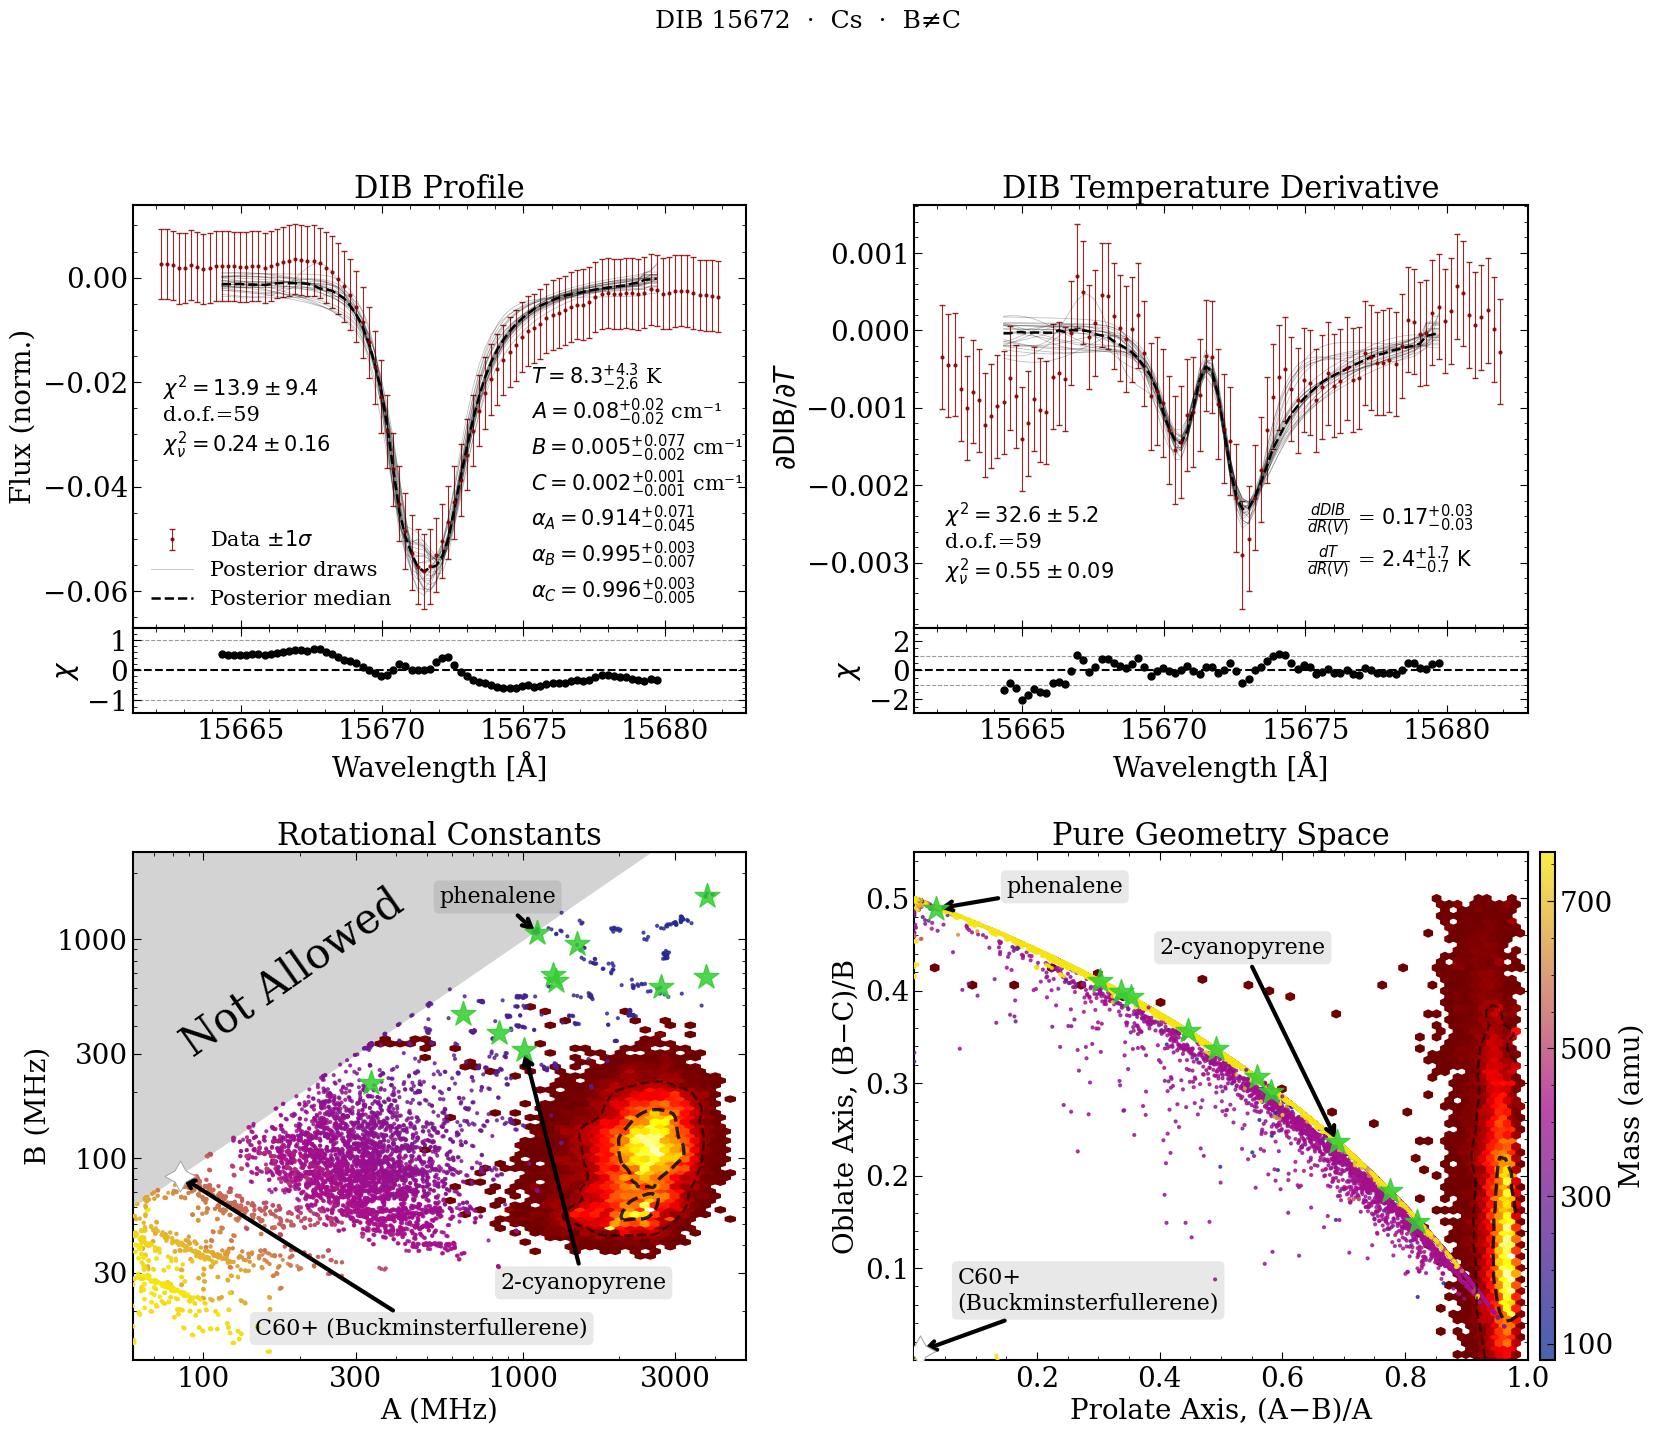

In [275]:
from matplotlib.gridspec import GridSpec, GridSpecFromSubplotSpec
from scipy.ndimage import gaussian_filter
try:
    _has_prof = pgo_available and models_dib is not None and len(models_dib) > 0
except NameError:
    _has_prof = False

eps = 1e-4
greenstarsize = 350
c60size = 500
extra_trunc = 0
oblate_max = 0.5

if dib_band =='15672':
    C15672 = True
else:
    C15672 = False

if dib_band =='15272':
    C15272 = True
else:
    C15272 = False
    
    
# ── Posterior rotational constants ──────────────────────────────────────────
post_A = flat_samples[:, 1].copy()
if B_not_equal_C:
    post_B = flat_samples[:, 2].copy()
    post_C = flat_samples[:, 3].copy()
elif inferred_sym == 'C2v':   # B = A stored; C separate
    post_B = flat_samples[:, 1].copy()
    post_C = flat_samples[:, 2].copy()
else:                          # Cs with B = C stored as BC
    post_B = flat_samples[:, 2].copy()
    post_C = flat_samples[:, 2].copy()

_phys = (post_B > 1e-4) & (post_B < 100)
post_A, post_B, post_C = post_A[_phys], post_B[_phys], post_C[_phys]
_sw = post_C > post_B
post_B[_sw], post_C[_sw] = post_C[_sw].copy(), post_B[_sw].copy()

# ── Figure skeleton ─────────────────────────────────────────────────────────
fig21 = plt.figure(figsize=(18, 15), constrained_layout=False)
fig21.patch.set_facecolor('white')
outer = GridSpec(2, 2, figure=fig21, hspace=0.275, wspace=0.275)

gs_top = GridSpecFromSubplotSpec(2, 1, subplot_spec=outer[0, 0],
                                 height_ratios=[5, 1], hspace=0.0)
gs_bot = GridSpecFromSubplotSpec(2, 1, subplot_spec=outer[0, 1],
                                 height_ratios=[5, 1], hspace=0.0)

ax_dib_m = fig21.add_subplot(gs_top[0])
ax_dib_r = fig21.add_subplot(gs_top[1], sharex=ax_dib_m)
ax_dT_m  = fig21.add_subplot(gs_bot[0])
ax_dT_r  = fig21.add_subplot(gs_bot[1],  sharex=ax_dT_m)
ax_AB    = fig21.add_subplot(outer[1, 0])   # [0,1]  A vs B (MHz)
ax_geo   = fig21.add_subplot(outer[1, 1])   # [1,1]  geometry space

DARK_RED = '#8B0000'
_DARK_BG = '#1c1c1c'
_DARK_BG = '#FFFFFF'

# ── Helper: profile panel + residual ────────────────────────────────────────
def _plot_panel(ax_m, ax_r, data, err, models, med, ylabel, wav_f, wav_c, c, pull_f = 0.0, center_pull = False, legend = True):
    ax_m.errorbar(wav_f, data, yerr=err, fmt='o',
                  color=DARK_RED, ecolor=DARK_RED,
                  ms=2, elinewidth=0.8, capsize=2, alpha=0.85,
                  label=r'Data $\pm1\sigma$')
    pull_f = float(pull_f)
    mdl_cs = []
    print(c)
    for k, mdl in enumerate(models):
        if extra_trunc>0:
            mdl = mdl[extra_trunc:-extra_trunc]
        weights = np.vstack([[pull_f]*len(mdl), [1]*len(mdl)])
        if center_pull:
            weights[0,:] *= 1-2*np.abs( (np.arange(len(weights[0,:]))-len(weights[0,:])/2)/len(weights[0,:]) )
        mdl_c = np.average(np.vstack([gaussian_filter(data[c:-c], sigma = 1, mode = 'nearest'), mdl]), weights = weights, axis = 0)
        mdl_cs.append(mdl_c)
        ax_m.plot(wav_c, mdl_c, color='k', alpha=0.25, lw=0.6,
                  label=f'Posterior draws' if k == 0 else None)
    if pull_f>0:
        med = np.median(mdl_cs, axis = 0)
    ax_m.plot(wav_c, med, color='k', lw=1.8, ls='--', label='Posterior median')
    ax_m.set_ylabel(ylabel)
    if legend:
        handles, labels = ax_m.get_legend_handles_labels()
        ax_m.legend([handles[2], handles[0], handles[1]], [labels[2], labels[0], labels[1]], loc='lower left', frameon=False)
    ax_m.tick_params(labelbottom=False)

    chi = (data[c:-c] - med) / err[c:-c]
    ax_r.axhline(0,  color='k', lw=1.5, ls='--')
    ax_r.axhline(-1, color='k', lw=0.8, ls='--', alpha=0.4)
    ax_r.axhline( 1, color='k', lw=0.8, ls='--', alpha=0.4)
    ax_r.plot(wav_c, chi, 'ko', ms=5)
    ax_r.set_ylabel(r'$\chi$')
    ax_r.set_xlabel(r'Wavelength [Å]')
    fac = 1.4 * np.max( [1, np.max(np.abs(chi))] )
    ax_r.set_ylim(-fac, fac)
    if np.max(np.abs(chi)) < 1:
        ax_r.set_yticks([-1, 0, 1])
    else:
        ax_r.yaxis.set_major_locator(plt.MaxNLocator(3, symmetric=True))
#     ax_r.tick_params(labelsize=8)

param_fmts = ['.1f', '.2f', '.3f', '.3f', '.3f', '.3f', '.3f']  # one per label

param_txt = "\n".join(
    r"${name} = {med}^{{+{up}}}_{{-{lo}}}$ {unit}".format(
        name=name,
        med=f"{np.median(flat_samples[:, i]):{param_fmts[i]}}",
        up =f"{np.percentile(flat_samples[:, i], 84) - np.median(flat_samples[:, i]):{param_fmts[i]}}",
        lo =f"{np.median(flat_samples[:, i]) - np.percentile(flat_samples[:, i], 16):{param_fmts[i]}}",
        unit=unit,
    )
    for i, label in enumerate(labels[:-2])
    for name, unit in [parse_label(label)]
)


variation_fmts = ['.2f', '.1f', '.2f']  # one per label


variation_txt = "\n".join(
    r"{label} = ${med}^{{+{up}}}_{{-{lo}}}$ {unit}".format(
        label=label,
        med=f"{np.median(derived[:, i]):{variation_fmts[i]}}",
        up =f"{np.percentile(derived[:, i], 84) - np.median(derived[:, i]):{variation_fmts[i]}}",
        lo =f"{np.median(derived[:, i]) - np.percentile(derived[:, i], 16):{variation_fmts[i]}}",
        unit=derived_units[i],
    )
    for i, label in enumerate(derived_labels[:2])
)


# ── [0,0] and [1,0]: profile panels ─────────────────────────────────────────
if _has_prof:
    _c     = c_crop + extra_trunc
    _wav_f = data_wavelength
    _wav_c = data_wavelength[_c:-_c]
    try:
        _e_dib, _e_dT = err_sets[0][0], err_sets[0][1]
    except (NameError, IndexError):
        _e_dib, _e_dT = noise_std, noise_std_dT
    if redo_data:
        _e_dib, _e_dT = _noise_std, _noise_std_dT
    _med_dib = np.median(np.array(models_dib), axis=0)
    _med_dT  = np.median(np.array(models_dT),  axis=0)
    _plot_panel(ax_dib_m, ax_dib_r, data_flux,    _e_dib, models_dib,
                _med_dib, 'Flux (norm.)', _wav_f, _wav_c, _c)
    
    cv, cr, pv, dof, se_cv, se_cr, se_pv = chi2_stats(data_flux, models_dib, _e_dib, n_sc, extra_trunc = extra_trunc)
     
        
    if C15672:
        xy = (0.05, 0.6)
    if C15272:
        xy = (0.05, 0.6)
        
    ax_dib_m.annotate(
                f'$\\chi^2 = {cv:.1f} \\pm {se_cv:.1f}$\n'
                f'd.o.f.={dof}\n'
                f'$\\chi^2_\\nu = {cr:.2f} \\pm {se_cr:.2f}$',
                xy=(0.05, 0.6), xycoords='axes fraction',
                va='top', ha='left',
                bbox=dict(boxstyle='round,pad=0.3', fc='white', alpha=0))

    if C15672:
        xy = (0.65, 0.63)
    if C15272:
        xy = (0.65, 0.63)
        
    ax_dib_m.annotate(
        param_txt,
        xy=xy, xycoords='axes fraction',
        va='top', ha='left',
        bbox=dict(boxstyle='round,pad=0.3', fc='white', alpha=0))
    
    
    ax_dib_m.set_title('DIB Profile', pad=4)
    _plot_panel(ax_dT_m,  ax_dT_r,  data_flux_dT, _e_dT,  models_dT,
                _med_dT, r'$\partial\mathrm{DIB}/\partial T$', _wav_f, _wav_c, _c, legend = False)
#     ax_dT_m.set_title(r'$\partial\mathrm{DIB}/\partial T$', pad=4)
    ax_dT_m.set_title(r'DIB Temperature Derivative', pad=4)
# 
    
    cv, cr, pv, dof, se_cv, se_cr, se_pv = chi2_stats(data_flux_dT, models_dT, _e_dT, n_sc, extra_trunc = extra_trunc)
    
    if C15672:
        xy = (0.05, 0.3)
    if C15272:
        xy = (0.05, 0.3)
        
    ax_dT_m.annotate(
            f'$\\chi^2 = {cv:.1f} \\pm {se_cv:.1f}$\n'
            f'd.o.f.={dof}\n'
            f'$\\chi^2_\\nu = {cr:.2f} \\pm {se_cr:.2f}$',
            xy=xy, xycoords='axes fraction',
            va='top', ha='left',
            bbox=dict(boxstyle='round,pad=0.3', fc='white', alpha=0))
    
    if C15672:
        xy = (0.64, 0.3)        
    if C15272:
        xy = (0.7, 0.3)

    ax_dT_m.annotate(
        variation_txt,
        xy=xy, xycoords='axes fraction',
        va='top', ha='left',
        bbox=dict(boxstyle='round,pad=0.3', fc='white', alpha=0))

else:
    for _ax in (ax_dib_m, ax_dib_r, ax_dT_m, ax_dT_r):
        _ax.text(0.5, 0.5, 'No model spectra\n(pgo not available)',
                 ha='center', va='center', transform=_ax.transAxes)
        _ax.set_axis_off()

# ── [0,1]: A vs B (MHz) ──────────────────────────────────────────────────────


_pa = np.clip((post_A - post_B) / (post_A + 1e-30), eps, 1.0)
_oa = np.clip((post_B - post_C) / (post_B + 1e-30), eps, 1.0)
_omask = _oa < oblate_max

ax_AB.set_facecolor(_DARK_BG)
xtop, ytop = 5000, 2500

_xna = np.logspace(np.log10(60), np.log10(xtop), 500)
ax_AB.fill_between(_xna, _xna, ytop, color='lightgray', zorder=0)
ax_AB.text(190, 700, 'Not Allowed', color='black',
           rotation=35, ha='center', va='center', zorder=1, fontsize = 30)

ax_AB.hexbin(post_A[_omask] * cm2MHz, post_B[_omask] * cm2MHz,
             gridsize=50, xscale='log', yscale='log',
             cmap=dusk_cmap, mincnt=1, zorder=2)

# A vs B panel (log-scale)
_sigma_contours(ax_AB, post_A[_omask] * cm2MHz, post_B[_omask] * cm2MHz,
                fwd=np.log10, inv=lambda v: 10**v)


_db_ok = ~radio_mask & (ABCmat[1, :] > 0)
sc_AB  = ax_AB.scatter(ABCmat[2, _db_ok] * cm2MHz, ABCmat[1, _db_ok] * cm2MHz,
                       c=Mmat[_db_ok], cmap=bmy_cmap, vmin=78, vmax=766,
                       s=4, zorder=3, alpha = 0.75)

_geo_pos = {}
for mol, (rA, rB, rC) in radio_const.items():
    ax_AB.scatter(rA, rB, color='limegreen', marker='*', s=greenstarsize, zorder=5, alpha=0.85)
    _geo_pos[mol] = (rA, rB, rC)

if len(c60p_idx):
    _A60 = ABCmat[2, c60p_idx[0]] * cm2MHz
    _B60 = ABCmat[1, c60p_idx[0]] * cm2MHz
    ax_AB.scatter(_A60, _B60, color='white', marker=(4,1,0), s=c60size,
                  zorder=6, edgecolors='#aaa', lw=0.8)

_ann_kw = dict(fontsize=16, color='black',
               arrowprops=dict(arrowstyle='->', color='black', lw=3.0),
               bbox=dict(boxstyle='round,pad=0.25', fc='#222', ec='none', alpha=0.1))

ax_AB.annotate('C60+ (Buckminsterfullerene)',
               xy=(_A60, _B60),
               xytext=(0.2, 0.05), textcoords='axes fraction', **_ann_kw)
if '2-cyanopyrene' in _geo_pos:
    rA, rB, _ = _geo_pos['2-cyanopyrene']
    ax_AB.annotate('2-cyanopyrene', xy=(rA, rB),
                   xytext=(0.6, 0.14), textcoords='axes fraction', **_ann_kw)
if 'phenalene' in _geo_pos:
    rA, rB, _ = _geo_pos['phenalene']
    ax_AB.annotate('phenalene', xy=(rA, rB),
                   xytext=(0.5, 0.9), textcoords='axes fraction', **_ann_kw)

ax_AB.set_xscale('log');  ax_AB.set_yscale('log')
ax_AB.set_xlim(60, xtop); ax_AB.set_ylim(12, ytop)
ax_AB.set_xticks([100, 300, 1000, 3000])
ax_AB.set_xticklabels(['100', '300', '1000', '3000'])
ax_AB.set_yticks([30, 100, 300, 1000])
ax_AB.set_yticklabels(['30', '100', '300', '1000'])
ax_AB.set_xlabel('A (MHz)'); ax_AB.set_ylabel('B (MHz)')
ax_AB.set_title('Rotational Constants', pad=4)

# cb_AB = fig21.colorbar(sc_AB, ax=ax_AB, fraction=0.046, pad=0.02)
# cb_AB.set_label('Mass (amu)', fontsize=9)
# cb_AB.set_ticks([100, 300, 500, 700])

# ── [1,1]: Geometry space (A-B)/A vs (B-C)/B ────────────────────────────────
ax_geo.set_facecolor(_DARK_BG)
eps = 1e-4

_pa = np.clip((post_A - post_B) / (post_A + 1e-30), eps, 1.0)
_oa = np.clip((post_B - post_C) / (post_B + 1e-30), eps, 1.0)
ax_geo.hexbin(_pa[_omask], _oa[_omask], gridsize=70, xscale='linear', yscale='linear',
              cmap=dusk_cmap, mincnt=1, zorder=2)

# Geometry panel (FuncScale)
_sigma_contours(ax_geo, _pa[_omask], _oa[_omask])

_vld = ABCmat[2, :] > 0
_pd  = np.clip((ABCmat[2,_vld]-ABCmat[1,_vld])/(ABCmat[2,_vld]+1e-30), eps, 1.0)
_od  = np.clip((ABCmat[1,_vld]-ABCmat[0,_vld])/(ABCmat[1,_vld]+1e-30), eps, 1.0)
sc_g = ax_geo.scatter(_pd, _od, c=Mmat[_vld], cmap=bmy_cmap,
                      vmin=78, vmax=766, s=4, zorder=3, alpha = 0.75)

_rg = {}
for mol, (rA, rB, rC) in radio_const.items():
    p = max((rA - rB) / rA, eps)
    o = max((rB - rC) / rB, eps)
    ax_geo.scatter(p, o, color='limegreen', marker='*', s=greenstarsize, zorder=5, alpha=0.85)
    _rg[mol] = (p, o)

# C60+: spherical top → prolate = oblate ≈ 0; clipped to eps
ax_geo.scatter(eps*100, eps*100, color='white', marker=(4,1,0), s=c60size,
               zorder=6, edgecolors='#aaa', lw=0.8)

ax_geo.annotate('C60+\n(Buckminsterfullerene)',
                xy=(eps*100, eps*100),
                xytext=(0.07, 0.10), textcoords='axes fraction', **_ann_kw)

if '2-cyanopyrene' in _rg:
    ax_geo.annotate('2-cyanopyrene', xy=_rg['2-cyanopyrene'],
                    xytext=(0.4, 0.80), textcoords='axes fraction', **_ann_kw)
if 'phenalene' in _rg:
    ax_geo.annotate('phenalene', xy=_rg['phenalene'],
                    xytext=(0.15, 0.92), textcoords='axes fraction', **_ann_kw)

oblate_lim  = np.max( [0.55, oblate_max*1.05] )
ax_geo.set_xscale('linear');  ax_geo.set_yscale('linear')
ax_geo.set_xlim(5e-4, 1.0); ax_geo.set_ylim(5e-4, oblate_lim)


ax_geo.set_xlabel('Prolate Axis, (A−B)/A')
ax_geo.set_ylabel('Oblate Axis, (B−C)/B')
ax_geo.set_title('Pure Geometry Space', pad=4)

cax_g = ax_geo.inset_axes([1.02, 0.0, 0.025, 1])
cb_g  = fig21.colorbar(sc_g, cax=cax_g)
cb_g.set_label('Mass (amu)', color='black')
cb_g.set_ticks([100, 300, 500, 700])
# cb_g.ax.yaxis.set_tick_params(color='white', labelcolor='white')

fig21.suptitle(
    f'DIB {inferred_dib}  ·  {inferred_sym}  ·  '
    f'{"B≠C" if B_not_equal_C else "B=C"}', y=1.01)

if save_fig:
    fig21.savefig(os.path.join(FIG_DIR, 'summary_2x2.pdf'), bbox_inches='tight')
plt.show()


In [276]:
from matplotlib.gridspec import GridSpec, GridSpecFromSubplotSpec
from scipy.ndimage import gaussian_filter
from matplotlib.lines import Line2D

10
10


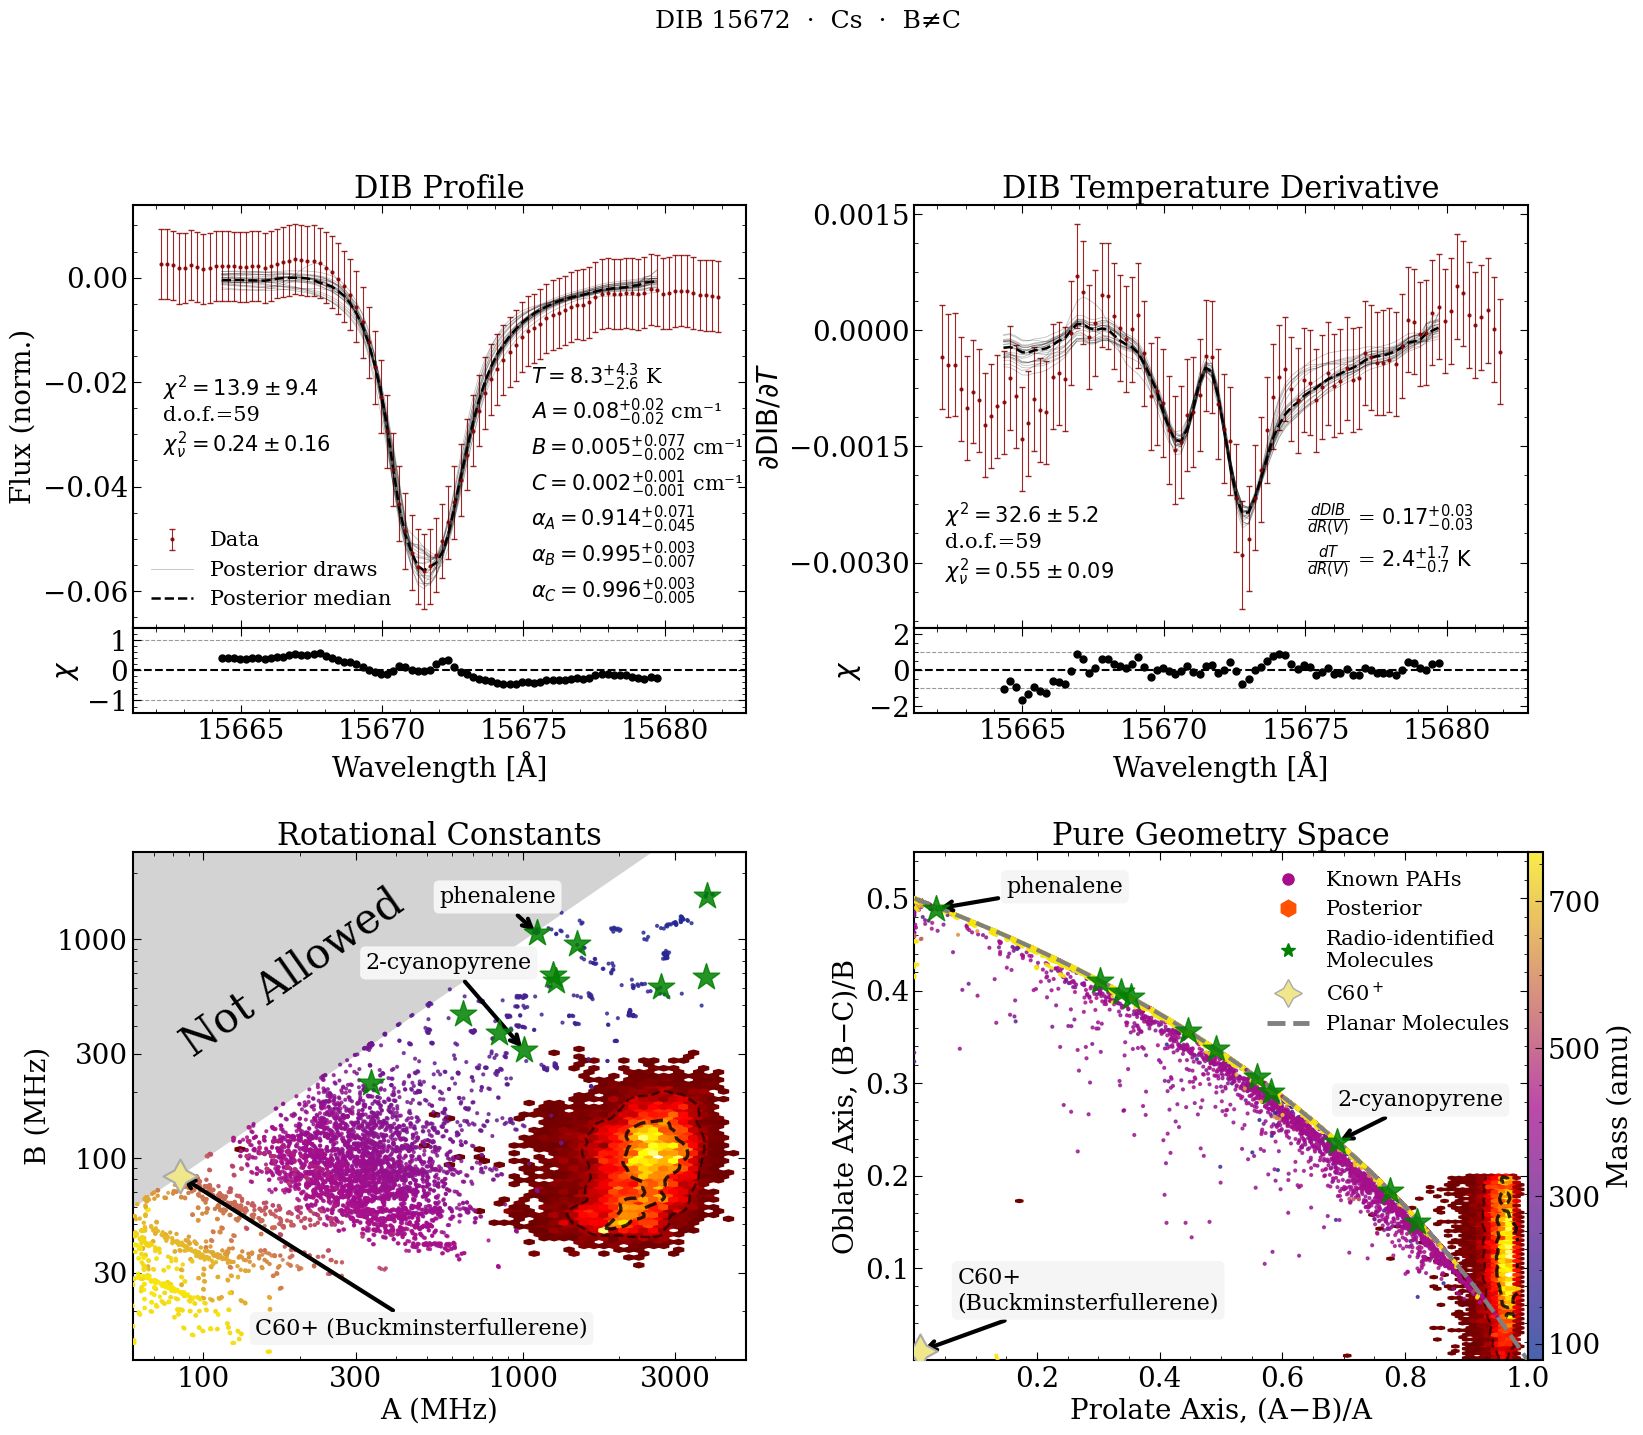

In [277]:
# ── Display controls ─────────────────────────────────────────────────────────
N_MAIN_YTICKS      = 5
N_RESIDUAL_YTICKS  = 3
STAR_COLOR         = 'green'
c60color           = 'khaki'
ANN_FC             = 'whitesmoke'
ANN_ALPHA          = 1.0
eps = 1e-4
greenstarsize = 400
c60size = 600
extra_trunc = 0
oblate_max = 0.2

try:
    _has_prof = pgo_available and models_dib is not None and len(models_dib) > 0
except NameError:
    _has_prof = False

if dib_band == '15672':
    C15672 = True
else:
    C15672 = False

if dib_band == '15272':
    C15272 = True
else:
    C15272 = False

# ── Shared annotation styles ─────────────────────────────────────────────────
_ann_kw   = dict(fontsize=16, color='black',
                 arrowprops=dict(arrowstyle='->', color='black', lw=3.0),
                 bbox=dict(boxstyle='round,pad=0.25', fc=ANN_FC, ec='none', alpha=ANN_ALPHA))

# ── Posterior rotational constants ───────────────────────────────────────────
post_A = flat_samples[:, 1].copy()
if B_not_equal_C:
    post_B = flat_samples[:, 2].copy()
    post_C = flat_samples[:, 3].copy()
elif inferred_sym == 'C2v':
    post_B = flat_samples[:, 1].copy()
    post_C = flat_samples[:, 2].copy()
else:
    post_B = flat_samples[:, 2].copy()
    post_C = flat_samples[:, 2].copy()

_phys = (post_B > 1e-4) & (post_B < 100)
post_A, post_B, post_C = post_A[_phys], post_B[_phys], post_C[_phys]
_sw = post_C > post_B
post_B[_sw], post_C[_sw] = post_C[_sw].copy(), post_B[_sw].copy()

# ── Figure skeleton ──────────────────────────────────────────────────────────
fig21 = plt.figure(figsize=(18, 15), constrained_layout=False)
fig21.patch.set_facecolor('white')
outer = GridSpec(2, 2, figure=fig21, hspace=0.275, wspace=0.275)

gs_top = GridSpecFromSubplotSpec(2, 1, subplot_spec=outer[0, 0],
                                 height_ratios=[5, 1], hspace=0.0)
gs_bot = GridSpecFromSubplotSpec(2, 1, subplot_spec=outer[0, 1],
                                 height_ratios=[5, 1], hspace=0.0)

ax_dib_m = fig21.add_subplot(gs_top[0])
ax_dib_r = fig21.add_subplot(gs_top[1], sharex=ax_dib_m)
ax_dT_m  = fig21.add_subplot(gs_bot[0])
ax_dT_r  = fig21.add_subplot(gs_bot[1], sharex=ax_dT_m)
ax_AB    = fig21.add_subplot(outer[1, 0])
ax_geo   = fig21.add_subplot(outer[1, 1])

DARK_RED = '#8B0000'
_DARK_BG = '#FFFFFF'

# ── Helper: profile panel + residual ────────────────────────────────────────
def _plot_panel(ax_m, ax_r, data, err, models, med, ylabel, wav_f, wav_c, c,
                pull_f=0.3, center_pull=False, legend=True):
    ax_m.errorbar(wav_f, data, yerr=err, fmt='o',
                  color=DARK_RED, ecolor=DARK_RED,
                  ms=2, elinewidth=0.8, capsize=2, alpha=0.85,
                  label=r'Data')
    pull_f = float(pull_f)
    mdl_cs = []
    print(c)
    for k, mdl in enumerate(models):
        if extra_trunc > 0:
            mdl = mdl[extra_trunc:-extra_trunc]
        weights = np.vstack([[pull_f] * len(mdl), [1] * len(mdl)])
        if center_pull:
            weights[0, :] *= 1 - 2 * np.abs(
                (np.arange(len(weights[0, :])) - len(weights[0, :]) / 2) / len(weights[0, :]))
        mdl_c = np.average(
            np.vstack([gaussian_filter(data[c:-c], sigma=1, mode='nearest'), mdl]),
            weights=weights, axis=0)
        mdl_cs.append(mdl_c)
        ax_m.plot(wav_c, mdl_c, color='k', alpha=0.25, lw=0.6,
                  label='Posterior draws' if k == 0 else None)
    if pull_f > 0:
        med = np.median(mdl_cs, axis=0)
    ax_m.plot(wav_c, med, color='k', lw=1.8, ls='--', label='Posterior median')
    ax_m.set_ylabel(ylabel)
    ax_m.yaxis.set_major_locator(plt.MaxNLocator(N_MAIN_YTICKS))
    
    if legend:
        handles, labels = ax_m.get_legend_handles_labels()
        ax_m.legend([handles[2], handles[0], handles[1]],
                    [labels[2],  labels[0],  labels[1]],
                    loc='lower left', frameon=False)
    ax_m.tick_params(labelbottom=False)

    chi = (data[c:-c] - med) / err[c:-c]
    ax_r.axhline( 0, color='k', lw=1.5, ls='--')
    ax_r.axhline(-1, color='k', lw=0.8, ls='--', alpha=0.4)
    ax_r.axhline( 1, color='k', lw=0.8, ls='--', alpha=0.4)
    ax_r.plot(wav_c, chi, 'ko', ms=5)
    ax_r.set_ylabel(r'$\chi$')
    ax_r.set_xlabel(r'Wavelength [Å]')
    fac = 1.4 * np.max([1, np.max(np.abs(chi))])
    ax_r.set_ylim(-fac, fac)
    ax_r.yaxis.set_major_locator(plt.MaxNLocator(N_RESIDUAL_YTICKS, symmetric=True))


param_fmts = ['.1f', '.2f', '.3f', '.3f', '.3f', '.3f', '.3f']

param_txt = "\n".join(
    r"${name} = {med}^{{+{up}}}_{{-{lo}}}$ {unit}".format(
        name=name,
        med=f"{np.median(flat_samples[:, i]):{param_fmts[i]}}",
        up =f"{np.percentile(flat_samples[:, i], 84) - np.median(flat_samples[:, i]):{param_fmts[i]}}",
        lo =f"{np.median(flat_samples[:, i]) - np.percentile(flat_samples[:, i], 16):{param_fmts[i]}}",
        unit=unit,
    )
    for i, label in enumerate(labels[:-2])
    for name, unit in [parse_label(label)]
)

param_txt = "\n".join(
    r"${name} = {med}^{{+{up}}}_{{-{lo}}}$ {unit}".format(
        name=name,
        med=f"{np.median(flat_samples2[:, i]):{param_fmts[i]}}",
        up =f"{np.percentile(flat_samples2[:, i], 84) - np.median(flat_samples2[:, i]):{param_fmts[i]}}",
        lo =f"{np.median(flat_samples2[:, i]) - np.percentile(flat_samples2[:, i], 16):{param_fmts[i]}}",
        unit=unit,
    )
    for i, label in enumerate(labels[:-2])
    for name, unit in [parse_label(label)]
)

variation_fmts = ['.2f', '.1f', '.2f']

variation_txt = "\n".join(
    r"{label} = ${med}^{{+{up}}}_{{-{lo}}}$ {unit}".format(
        label=label,
        med=f"{np.median(derived[:, i]):{variation_fmts[i]}}",
        up =f"{np.percentile(derived[:, i], 84) - np.median(derived[:, i]):{variation_fmts[i]}}",
        lo =f"{np.median(derived[:, i]) - np.percentile(derived[:, i], 16):{variation_fmts[i]}}",
        unit=derived_units[i],
    )
    for i, label in enumerate(derived_labels[:2])
)

# ── Profile panels ───────────────────────────────────────────────────────────
if _has_prof:
    _c     = c_crop + extra_trunc
    _wav_f = data_wavelength
    _wav_c = data_wavelength[_c:-_c]
    try:
        _e_dib, _e_dT = err_sets[0][0], err_sets[0][1]
    except (NameError, IndexError):
        _e_dib, _e_dT = noise_std, noise_std_dT
    if redo_data:
        _e_dib, _e_dT = _noise_std, _noise_std_dT
    _med_dib = np.median(np.array(models_dib), axis=0)
    _med_dT  = np.median(np.array(models_dT),  axis=0)

    _plot_panel(ax_dib_m, ax_dib_r, data_flux, _e_dib, models_dib,
                _med_dib, 'Flux (norm.)', _wav_f, _wav_c, _c)

    cv, cr, pv, dof, se_cv, se_cr, se_pv = chi2_stats(
        data_flux, models_dib, _e_dib, n_sc, extra_trunc=extra_trunc)

    if C15672 or C15272:
        xy_chi  = (0.05, 0.6)
        xy_par  = (0.65, 0.63)

    ax_dib_m.annotate(
        f'$\\chi^2 = {cv:.1f} \\pm {se_cv:.1f}$\n'
        f'd.o.f.={dof}\n'
        f'$\\chi^2_\\nu = {cr:.2f} \\pm {se_cr:.2f}$',
        xy=xy_chi, xycoords='axes fraction',
        va='top', ha='left')

    ax_dib_m.annotate(
        param_txt,
        xy=xy_par, xycoords='axes fraction',
        va='top', ha='left')

    ax_dib_m.set_title('DIB Profile', pad=4)

    _plot_panel(ax_dT_m, ax_dT_r, data_flux_dT, _e_dT, models_dT,
                _med_dT, r'$\partial\mathrm{DIB}/\partial T$', _wav_f, _wav_c, _c,
                legend=False)
    ax_dT_m.set_title(r'DIB Temperature Derivative', pad=4)

    cv, cr, pv, dof, se_cv, se_cr, se_pv = chi2_stats(
        data_flux_dT, models_dT, _e_dT, n_sc, extra_trunc=extra_trunc)

    if C15672:
        xy_chi2 = (0.05, 0.3)
        xy_var  = (0.64, 0.3)
    if C15272:
        xy_chi2 = (0.05, 0.3)
        xy_var  = (0.7,  0.3)

    ax_dT_m.annotate(
        f'$\\chi^2 = {cv:.1f} \\pm {se_cv:.1f}$\n'
        f'd.o.f.={dof}\n'
        f'$\\chi^2_\\nu = {cr:.2f} \\pm {se_cr:.2f}$',
        xy=xy_chi2, xycoords='axes fraction',
        va='top', ha='left')

    ax_dT_m.annotate(
        variation_txt,
        xy=xy_var, xycoords='axes fraction',
        va='top', ha='left')

else:
    for _ax in (ax_dib_m, ax_dib_r, ax_dT_m, ax_dT_r):
        _ax.text(0.5, 0.5, 'No model spectra\n(pgo not available)',
                 ha='center', va='center', transform=_ax.transAxes)
        _ax.set_axis_off()

# ── A vs B (MHz) ─────────────────────────────────────────────────────────────
_pa = np.clip((post_A - post_B) / (post_A + 1e-30), eps, 1.0)
_oa = np.clip((post_B - post_C) / (post_B + 1e-30), eps, 1.0)
_omask = _oa < oblate_max

ax_AB.set_facecolor(_DARK_BG)
xtop, ytop = 5000, 2500

_xna = np.logspace(np.log10(60), np.log10(xtop), 500)
ax_AB.fill_between(_xna, _xna, ytop, color='lightgray', zorder=0)
ax_AB.text(190, 700, 'Not Allowed', color='black',
           rotation=35, ha='center', va='center', zorder=1, fontsize=30)

ax_AB.hexbin(post_A[_omask] * cm2MHz, post_B[_omask] * cm2MHz,
             gridsize=50, xscale='log', yscale='log',
             cmap=dusk_cmap, mincnt=1, zorder=2)

_sigma_contours(ax_AB, post_A[_omask] * cm2MHz, post_B[_omask] * cm2MHz,
                fwd=np.log10, inv=lambda v: 10**v)

_db_ok = ~radio_mask & (ABCmat[1, :] > 0)
sc_AB  = ax_AB.scatter(ABCmat[2, _db_ok] * cm2MHz, ABCmat[1, _db_ok] * cm2MHz,
                       c=Mmat[_db_ok], cmap=bmy_cmap, vmin=78, vmax=766,
                       s=4, zorder=3, alpha=0.75)

_geo_pos = {}
for mol, (rA, rB, rC) in radio_const.items():
    ax_AB.scatter(rA, rB, color=STAR_COLOR, marker='*', s=greenstarsize,
                  zorder=5, alpha=0.85)
    _geo_pos[mol] = (rA, rB, rC)

if len(c60p_idx):
    _A60 = ABCmat[2, c60p_idx[0]] * cm2MHz
    _B60 = ABCmat[1, c60p_idx[0]] * cm2MHz
    ax_AB.scatter(_A60, _B60, color=c60color, marker=(4, 1, 0), s=c60size,
                  zorder=6, edgecolors='#aaa', lw=1.5)

ax_AB.annotate('C60+ (Buckminsterfullerene)',
               xy=(_A60, _B60),
               xytext=(0.2, 0.05), textcoords='axes fraction', **_ann_kw)

if '2-cyanopyrene' in _geo_pos:
    rA, rB, _ = _geo_pos['2-cyanopyrene']
    ax_AB.annotate('2-cyanopyrene', xy=(rA, rB),
                   xytext=(0.38, 0.77), textcoords='axes fraction', **_ann_kw)
    
if 'phenalene' in _geo_pos:
    rA, rB, _ = _geo_pos['phenalene']
    ax_AB.annotate('phenalene', xy=(rA, rB),
                   xytext=(0.5, 0.9), textcoords='axes fraction', **_ann_kw)

ax_AB.set_xscale('log');  ax_AB.set_yscale('log')
ax_AB.set_xlim(60, xtop); ax_AB.set_ylim(12, ytop)
ax_AB.set_xticks([100, 300, 1000, 3000])
ax_AB.set_xticklabels(['100', '300', '1000', '3000'])
ax_AB.set_yticks([30, 100, 300, 1000])
ax_AB.set_yticklabels(['30', '100', '300', '1000'])
ax_AB.set_xlabel('A (MHz)'); ax_AB.set_ylabel('B (MHz)')
ax_AB.set_title('Rotational Constants', pad=4)

# ── Geometry space ────────────────────────────────────────────────────────────
ax_geo.set_facecolor(_DARK_BG)

_pa = np.clip((post_A - post_B) / (post_A + 1e-30), eps, 1.0)
_oa = np.clip((post_B - post_C) / (post_B + 1e-30), eps, 1.0)
ax_geo.hexbin(_pa[_omask], _oa[_omask], gridsize=70,
              cmap=dusk_cmap, mincnt=1, zorder=2)

_sigma_contours(ax_geo, _pa[_omask], _oa[_omask])

_vld = ABCmat[2, :] > 0
_pd  = np.clip((ABCmat[2, _vld] - ABCmat[1, _vld]) / (ABCmat[2, _vld] + 1e-30), eps, 1.0)
_od  = np.clip((ABCmat[1, _vld] - ABCmat[0, _vld]) / (ABCmat[1, _vld] + 1e-30), eps, 1.0)
sc_g = ax_geo.scatter(_pd, _od, c=Mmat[_vld], cmap=bmy_cmap,
                      vmin=78, vmax=766, s=4, zorder=3, alpha=0.75,
                      label='Known PAHs')

_rg = {}
for mol, (rA, rB, rC) in radio_const.items():
    p = max((rA - rB) / rA, eps)
    o = max((rB - rC) / rB, eps)
    ax_geo.scatter(p, o, color=STAR_COLOR, marker='*', s=greenstarsize,
                   zorder=5, alpha=0.85)
    _rg[mol] = (p, o)

ax_geo.scatter(eps * 100, eps * 100, color=c60color, marker=(4, 1, 0), s=c60size,
               zorder=6, edgecolors='#aaa', lw=1.5)

ax_geo.annotate('C60+\n(Buckminsterfullerene)',
                xy=(eps * 100, eps * 100),
                xytext=(0.07, 0.10), textcoords='axes fraction', **_ann_kw)
if '2-cyanopyrene' in _rg:
    ax_geo.annotate('2-cyanopyrene', xy=_rg['2-cyanopyrene'],
                    xytext=(0.69, 0.50), textcoords='axes fraction', **_ann_kw)
if 'phenalene' in _rg:
    ax_geo.annotate('phenalene', xy=_rg['phenalene'],
                    xytext=(0.15, 0.92), textcoords='axes fraction', **_ann_kw)

# ── Planar molecules line: oblate = (1 - prolate) / (2 - prolate) ────────────
_x_planar = np.linspace(5e-4, 1.0, 500)
_y_planar = (1 - _x_planar) / (2 - _x_planar)
ax_geo.plot(_x_planar, _y_planar, color='gray', lw=3, ls='--', zorder=4)

oblate_lim = np.max([0.55, oblate_max * 1.05])
ax_geo.set_xscale('linear'); ax_geo.set_yscale('linear')       
ax_geo.set_xlim(5e-4, 1.0);  ax_geo.set_ylim(5e-4, oblate_lim)
ax_geo.set_xlabel('Prolate Axis, (A−B)/A')
ax_geo.set_ylabel('Oblate Axis, (B−C)/B')
ax_geo.set_title('Pure Geometry Space', pad=4)

cax_g = ax_geo.inset_axes([1.00, 0.0, 0.025, 1])
cb_g  = fig21.colorbar(sc_g, cax=cax_g)
cb_g.set_label('Mass (amu)', color='black')
cb_g.set_ticks([100, 300, 500, 700])

# ── Combined legend for bottom row, placed in ax_geo upper right ─────────────
_leg_handles = [
   Line2D([0], [0], marker='o', ls='None', markersize=8,
           color=bmy_cmap(0.5), label='Known PAHs'),
    Line2D([0], [0], marker='h', ls='None', markersize=12,
           color=dusk_cmap(0.4), label='Posterior'),
    Line2D([0], [0], color=STAR_COLOR, marker='*', ls='None',
           markersize=10, label='Radio-identified\nMolecules'),
    Line2D([0], [0], color = c60color, marker=(4, 1, 0), ls='None',
           markersize=20, markeredgecolor='#aaa', label='C60+'),
    Line2D([0], [0], color='gray', lw=3.5, ls='--', label='Planar molecules'),
]
_leg_labels = ['Known PAHs', 'Posterior', 'Radio-identified\nMolecules',
               r'C60$^+$', 'Planar Molecules']

ax_geo.legend(_leg_handles, _leg_labels,
              loc='upper right', framealpha=0, facecolor=ANN_FC)

# ── Suptitle and save ─────────────────────────────────────────────────────────
fig21.suptitle(
    f'DIB {inferred_dib}  ·  {inferred_sym}  ·  '
    f'{"B≠C" if B_not_equal_C else "B=C"}', y=1.01)

if save_fig:
    fig21.savefig(os.path.join(FIG_DIR, 'summary_2x2.pdf'), bbox_inches='tight')
plt.show()

In [278]:
def chi2_stats_updated(data, models, err, n_sc, extra_trunc=0):
    """Like chi2_stats but returns 16th/84th percentile errors instead of std."""
    c = c_crop + extra_trunc
    d = data[c:-c]
    e = err[c:-c]
    dof = len(d)  - ndim - n_sc  # same dof logic as original

    chi2_samples = []
    for mdl in models:
        if extra_trunc > 0:
            mdl = mdl[extra_trunc:-extra_trunc]
        chi2_samples.append(np.sum(((d - mdl) / e) ** 2))
    chi2_samples = np.array(chi2_samples)
    cr_samples   = chi2_samples / dof

    cv    = np.median(chi2_samples)
    cr    = np.median(cr_samples)
    cv_lo = cv - np.percentile(chi2_samples, 16)
    cv_hi = np.percentile(chi2_samples, 84) - cv
    cr_lo = cr - np.percentile(cr_samples,   16)
    cr_hi = np.percentile(cr_samples,   84) - cr

    # p-value from median chi2
    from scipy.stats import chi2 as chi2_dist
    pv = 1 - chi2_dist.cdf(cv, dof)

    return cv, cr, pv, dof, cv_lo, cv_hi, cr_lo, cr_hi

ABCmat shape: (3, 10890)   Ready.
25
25


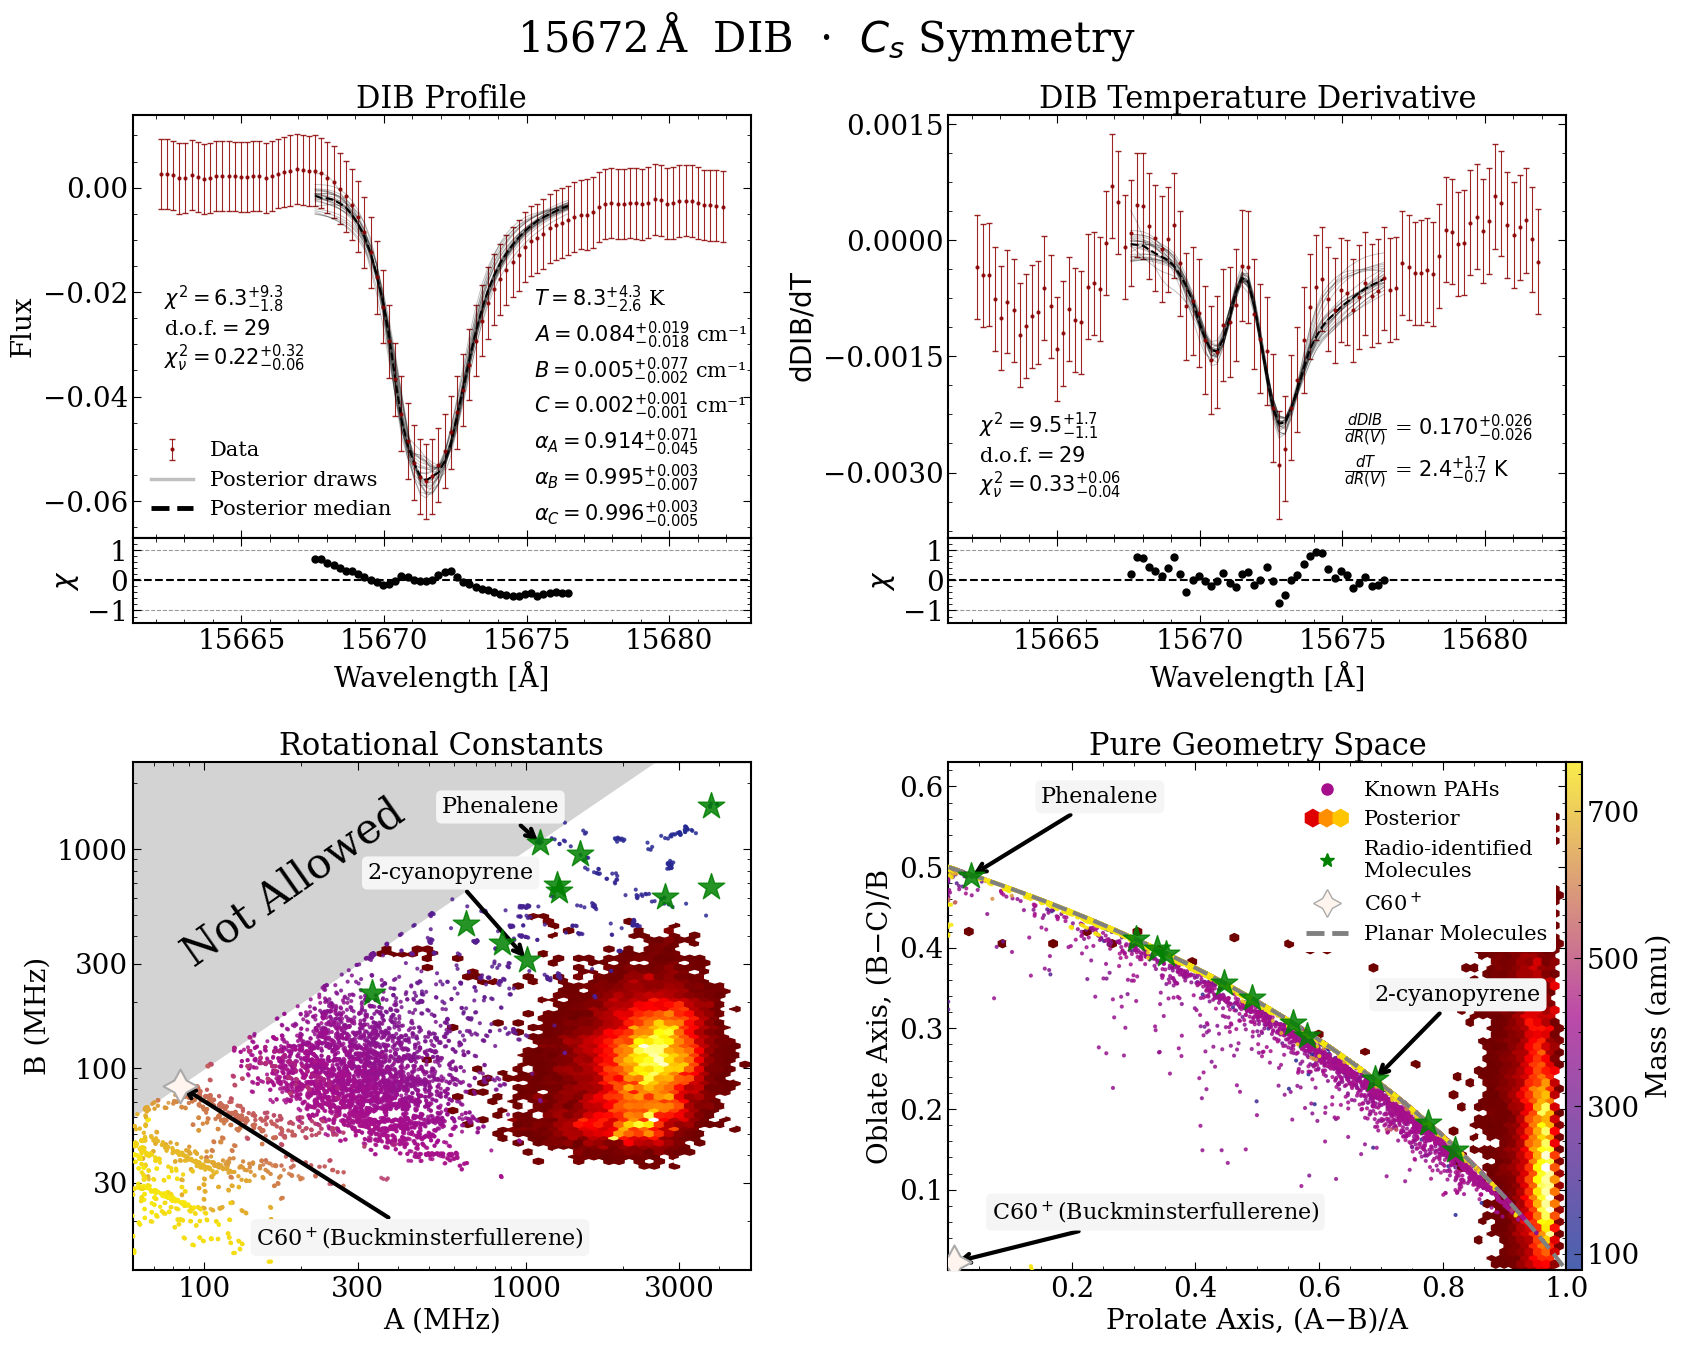

In [283]:
# ── Display controls ─────────────────────────────────────────────────────────
N_MAIN_YTICKS      = 5
N_RESIDUAL_YTICKS  = 3
STAR_COLOR         = 'green'
c60color           = 'seashell'
ANN_FC             = 'whitesmoke'
ANN_ALPHA          = 1.0
eps = 1e-4
greenstarsize = 400
c60size = 600
extra_trunc = 15
oblate_max = 0.6
posterior_min = 0
posterior_alpha = 1.0
nsigma = 0

# ── Colormaps ────────────────────────────────────────────────────────────────
# blue → magenta → yellow  (≈ colorcet/bmy)
bmy_cmap = mcolors.LinearSegmentedColormap.from_list(
    'bmy', [(0.05,0.18,0.58),(0.65,0.05,0.55),(0.97,0.90,0.05)], N=256)

# transparent → magma  (≈ CMasher dusk; transparent = empty hexbins invisible)
# _m        = plt.cm.magma(np.linspace(0.15, 1.0, 255))
_m        = plt.cm.hot(np.linspace(0.15, 1.0, 255))

dusk_cmap = mcolors.ListedColormap(np.vstack([[[1,1,1,0]], _m]))
# dusk_cmap = mcolors.ListedColormap(_m)
dusk_cmap.set_under('white') 

print(f'ABCmat shape: {ABCmat.shape}   Ready.')

try:
    _has_prof = pgo_available and models_dib is not None and len(models_dib) > 0
except NameError:
    _has_prof = False

if dib_band == '15672':
    C15672 = True
else:
    C15672 = False

if dib_band == '15272':
    C15272 = True
else:
    C15272 = False

# ── Shared annotation styles ─────────────────────────────────────────────────
_ann_kw   = dict(fontsize=16, color='black',
                 arrowprops=dict(arrowstyle='->', color='black', lw=3.0),
                 bbox=dict(boxstyle='round,pad=0.25', fc=ANN_FC, ec='none', alpha=ANN_ALPHA))

# ── Posterior rotational constants ───────────────────────────────────────────


post_A = flat_samples[:, 1].copy()
if B_not_equal_C:
    post_B = flat_samples[:, 2].copy()
    post_C = flat_samples[:, 3].copy()
else:
    post_B = flat_samples[:, 2].copy()
    post_C = flat_samples[:, 2].copy()

if inferred_sym == 'C2v' and dib_band == '15272':
    post_A = flat_samples[:, 3].copy()
    post_B = flat_samples[:, 2].copy()
    post_C = flat_samples[:, 1].copy()
    
if inferred_sym == 'C2v' and dib_band == '15672':
    post_A = flat_samples[:, 1].copy()
    post_B = flat_samples[:, 2].copy()
    post_C = flat_samples[:, 3].copy()
    
        
_phys = (post_B > 1e-4) & (post_B < 100)
post_A, post_B, post_C = post_A[_phys], post_B[_phys], post_C[_phys]
_sw = post_C > post_B
post_B[_sw], post_C[_sw] = post_C[_sw].copy(), post_B[_sw].copy()

# ── Figure skeleton ──────────────────────────────────────────────────────────
fig21 = plt.figure(figsize=(18.5, 15), constrained_layout=False)
fig21.patch.set_facecolor('white')
outer = GridSpec(2, 2, figure=fig21, hspace=0.275, wspace=0.32)

gs_top = GridSpecFromSubplotSpec(2, 1, subplot_spec=outer[0, 0],
                                 height_ratios=[5, 1], hspace=0.0)
gs_bot = GridSpecFromSubplotSpec(2, 1, subplot_spec=outer[0, 1],
                                 height_ratios=[5, 1], hspace=0.0)

ax_dib_m = fig21.add_subplot(gs_top[0])
ax_dib_r = fig21.add_subplot(gs_top[1], sharex=ax_dib_m)
ax_dT_m  = fig21.add_subplot(gs_bot[0])
ax_dT_r  = fig21.add_subplot(gs_bot[1], sharex=ax_dT_m)
ax_AB    = fig21.add_subplot(outer[1, 0])
ax_geo   = fig21.add_subplot(outer[1, 1])

DARK_RED = '#8B0000'
_DARK_BG = '#FFFFFF'

# ── Helper: profile panel + residual ────────────────────────────────────────
def _plot_panel(ax_m, ax_r, data, err, models, med, ylabel, wav_f, wav_c, c,
                pull_f=0.0, center_pull=False, legend=True):
    ax_m.errorbar(wav_f, data, yerr=err, fmt='o',
                  color=DARK_RED, ecolor=DARK_RED,
                  ms=2, elinewidth=0.8, capsize=2, alpha=0.85,
                  label=r'Data')
    pull_f = float(pull_f)
    mdl_cs = []
    print(c)
    for k, mdl in enumerate(models):
        if extra_trunc > 0:
            mdl = mdl[extra_trunc:-extra_trunc]
        weights = np.vstack([[pull_f] * len(mdl), [1] * len(mdl)])
        if center_pull:
            weights[0, :] *= 1 - 2 * np.abs(
                (np.arange(len(weights[0, :])) - len(weights[0, :]) / 2) / len(weights[0, :]))
        mdl_c = np.average(
            np.vstack([gaussian_filter(data[c:-c], sigma=1, mode='nearest'), mdl]),
            weights=weights, axis=0)
        mdl_cs.append(mdl_c)
        ax_m.plot(wav_c, mdl_c, color='k', alpha=0.25, lw=0.7,
                  label='Posterior draws' if k == 0 else None)
    if pull_f > 0:
        med = np.median(mdl_cs, axis=0)
    ax_m.plot(wav_c, med, color='k', lw=1.5, ls='--', label='Posterior median')
    ax_m.set_ylabel(ylabel)
    ax_m.yaxis.set_major_locator(plt.MaxNLocator(N_MAIN_YTICKS))
    
    if legend:
        
        from matplotlib.legend_handler import HandlerLine2D

        class _ThickLegendLine(HandlerLine2D):
            def __init__(self, lw=3, **kwargs):
                self._legend_lw = lw
                super().__init__(**kwargs)

            def create_artists(self, legend, orig_handle, *args, **kwargs):
                artists = super().create_artists(legend, orig_handle, *args, **kwargs)
                for a in artists:
                    a.set_linewidth(self._legend_lw)
                return artists
            
        handles, labels = ax_m.get_legend_handles_labels()
        ax_m.legend(
            [handles[2], handles[0], handles[1]],
            [labels[2],  labels[0],  labels[1]],
            loc='lower left', frameon=False,
            handler_map={
                handles[0]: _ThickLegendLine(lw=2.5),   # posterior draws
                handles[1]: _ThickLegendLine(lw=3.5),   # posterior median
            })
    ax_m.tick_params(labelbottom=False)

    chi = (data[c:-c] - med) / err[c:-c]
    ax_r.axhline( 0, color='k', lw=1.5, ls='--')
    ax_r.axhline(-1, color='k', lw=0.8, ls='--', alpha=0.4)
    ax_r.axhline( 1, color='k', lw=0.8, ls='--', alpha=0.4)
    ax_r.plot(wav_c, chi, 'ko', ms=5)
    ax_r.set_ylabel(r'$\chi$')
    ax_r.set_xlabel(r'Wavelength [Å]')
    fac = 1.4 * np.max([1, np.max(np.abs(chi))])
    ax_r.set_ylim(-fac, fac)
    ax_r.yaxis.set_major_locator(plt.MaxNLocator(N_RESIDUAL_YTICKS, symmetric=True))


param_fmts = ['.1f', '.3f', '.3f', '.3f', '.3f', '.3f', '.3f']

param_txt = "\n".join(
    r"${name} = {med}^{{+{up}}}_{{-{lo}}}$ {unit}".format(
        name=name,
        med=f"{np.median(flat_samples[:, i]):{param_fmts[i]}}",
        up =f"{np.percentile(flat_samples[:, i], 84) - np.median(flat_samples[:, i]):{param_fmts[i]}}",
        lo =f"{np.median(flat_samples[:, i]) - np.percentile(flat_samples[:, i], 16):{param_fmts[i]}}",
        unit=unit,
    )
    for i, label in enumerate(labels[:-2])
    for name, unit in [parse_label(label)]
)

# param_txt = "\n".join(
#     r"${name} = {med}^{{+{up}}}_{{-{lo}}}$ {unit}".format(
#         name=name,
#         med=f"{np.median(flat_samples2[:, i]):{param_fmts[i]}}",
#         up =f"{np.percentile(flat_samples2[:, i], 84) - np.median(flat_samples2[:, i]):{param_fmts[i]}}",
#         lo =f"{np.median(flat_samples2[:, i]) - np.percentile(flat_samples2[:, i], 16):{param_fmts[i]}}",
#         unit=unit,
#     )
#     for i, label in enumerate(labels[:-2])
#     for name, unit in [parse_label(label)]
# )

variation_fmts = ['.3f', '.1f', '.2f']

variation_txt = "\n".join(
    r"{label} = ${med}^{{+{up}}}_{{-{lo}}}$ {unit}".format(
        label=label,
        med=f"{np.median(derived[:, i]):{variation_fmts[i]}}",
        up =f"{np.percentile(derived[:, i], 84) - np.median(derived[:, i]):{variation_fmts[i]}}",
        lo =f"{np.median(derived[:, i]) - np.percentile(derived[:, i], 16):{variation_fmts[i]}}",
        unit=derived_units[i],
    )
    for i, label in enumerate(derived_labels[:2])
)

# ── Profile panels ───────────────────────────────────────────────────────────
if _has_prof:
    _c     = c_crop + extra_trunc
    _wav_f = data_wavelength
    _wav_c = data_wavelength[_c:-_c]
    try:
        _e_dib, _e_dT = err_sets[0][0], err_sets[0][1]
    except (NameError, IndexError):
        _e_dib, _e_dT = noise_std, noise_std_dT
    if redo_data:
        _e_dib, _e_dT = _noise_std, _noise_std_dT
    _med_dib = np.median(np.array(models_dib), axis=0)
    _med_dT  = np.median(np.array(models_dT),  axis=0)

    _plot_panel(ax_dib_m, ax_dib_r, data_flux, _e_dib, models_dib,
                _med_dib, 'Flux', _wav_f, _wav_c, _c)

    if C15672 or C15272:
        xy_chi  = (0.05, 0.6)
        xy_par  = (0.65, 0.6)

    cv, cr, pv, dof, cv_lo, cv_hi, cr_lo, cr_hi = chi2_stats_updated(
        data_flux, models_dib, _e_dib, n_sc, extra_trunc=extra_trunc)
    
    ax_dib_m.annotate(
        f'$\\chi^2 = {cv:.1f}^{{+{cv_hi:.1f}}}_{{-{cv_lo:.1f}}}$\n'
        f'd.o.f.$={dof}$\n'
        f'$\\chi^2_\\nu = {cr:.2f}^{{+{cr_hi:.2f}}}_{{-{cr_lo:.2f}}}$',
        xy=xy_chi, xycoords='axes fraction',
        va='top', ha='left')


    ax_dib_m.annotate(
        param_txt,
        xy=xy_par, xycoords='axes fraction',
        va='top', ha='left')

    ax_dib_m.set_title('DIB Profile', pad=4)

    _plot_panel(ax_dT_m, ax_dT_r, data_flux_dT, _e_dT, models_dT,
                _med_dT, r'$\mathrm{dDIB}/\mathrm{dT}$', _wav_f, _wav_c, _c,
                legend=False)
    ax_dT_m.set_title(r'DIB Temperature Derivative', pad=4)

    cv, cr, pv, dof, se_cv, se_cr, se_pv = chi2_stats(
        data_flux_dT, models_dT, _e_dT, n_sc, extra_trunc=extra_trunc)
    
    cv, cr, pv, dof, cv_lo, cv_hi, cr_lo, cr_hi = chi2_stats_updated(
        data_flux_dT, models_dT, _e_dT, n_sc, extra_trunc=extra_trunc)

    if C15672:
        xy_chi2 = (0.05, 0.3)
        xy_var  = (0.64, 0.3)
    if C15272:
        xy_chi2 = (0.05, 0.3)
        xy_var  = (0.65,  0.3)

#     ax_dT_m.annotate(
#         f'$\\chi^2 = {cv:.1f} \\pm {se_cv:.1f}$\n'
#         f'd.o.f.={dof}\n'
#         f'$\\chi^2_\\nu = {cr:.2f} \\pm {se_cr:.2f}$',
#         xy=xy_chi2, xycoords='axes fraction',
#         va='top', ha='left')

    ax_dT_m.annotate(
        f'$\\chi^2 = {cv:.1f}^{{+{cv_hi:.1f}}}_{{-{cv_lo:.1f}}}$\n'
        f'd.o.f.$={dof}$\n'
        f'$\\chi^2_\\nu = {cr:.2f}^{{+{cr_hi:.2f}}}_{{-{cr_lo:.2f}}}$',
        xy=xy_chi2, xycoords='axes fraction',
        va='top', ha='left')
        
    ax_dT_m.annotate(
        variation_txt,
        xy=xy_var, xycoords='axes fraction',
        va='top', ha='left')

else:
    for _ax in (ax_dib_m, ax_dib_r, ax_dT_m, ax_dT_r):
        _ax.text(0.5, 0.5, 'No model spectra\n(pgo not available)',
                 ha='center', va='center', transform=_ax.transAxes)
        _ax.set_axis_off()

# ── A vs B (MHz) ─────────────────────────────────────────────────────────────
_pa = np.clip((post_A - post_B) / (post_A + 1e-30), eps, 1.0)
_oa = np.clip((post_B - post_C) / (post_B + 1e-30), eps, 1.0)
_omask = _oa < oblate_max

ax_AB.set_facecolor(_DARK_BG)
xtop, ytop = 5000, 2500

_xna = np.logspace(np.log10(60), np.log10(xtop), 500)
ax_AB.fill_between(_xna, _xna, ytop, color='lightgray', zorder=0)
ax_AB.text(190, 700, 'Not Allowed', color='black',
           rotation=35, ha='center', va='center', zorder=1, fontsize=30)

ax_AB.hexbin(post_A[_omask] * cm2MHz, post_B[_omask] * cm2MHz,
             gridsize=50, xscale='log', yscale='log',
             cmap=dusk_cmap, mincnt=1, vmin = posterior_min, zorder=2, alpha = posterior_alpha)

_sigma_contours(ax_AB, post_A[_omask] * cm2MHz, post_B[_omask] * cm2MHz,
                fwd=np.log10, inv=lambda v: 10**v, nsigma = nsigma)

_db_ok = ~radio_mask & (ABCmat[1, :] > 0)
sc_AB  = ax_AB.scatter(ABCmat[2, _db_ok] * cm2MHz, ABCmat[1, _db_ok] * cm2MHz,
                       c=Mmat[_db_ok], cmap=bmy_cmap, vmin=78, vmax=766,
                       s=4, zorder=3, alpha=0.75)

_geo_pos = {}
for mol, (rA, rB, rC) in radio_const.items():
    ax_AB.scatter(rA, rB, color=STAR_COLOR, marker='*', s=greenstarsize,
                  zorder=5, alpha=0.85)
    _geo_pos[mol] = (rA, rB, rC)

if len(c60p_idx):
    _A60 = ABCmat[2, c60p_idx[0]] * cm2MHz
    _B60 = ABCmat[1, c60p_idx[0]] * cm2MHz
    ax_AB.scatter(_A60, _B60, color=c60color, marker=(4, 1, 0), s=c60size,
                  zorder=6, edgecolors='#aaa', lw=1.5)

ax_AB.annotate(r'C60$^+$(Buckminsterfullerene)',
               xy=(_A60, _B60),
               xytext=(0.2, 0.05), textcoords='axes fraction', **_ann_kw)

if '2-cyanopyrene' in _geo_pos:
    rA, rB, _ = _geo_pos['2-cyanopyrene']
    ax_AB.annotate('2-cyanopyrene', xy=(rA, rB),
                   xytext=(0.38, 0.77), textcoords='axes fraction', **_ann_kw)
    
if 'phenalene' in _geo_pos:
    rA, rB, _ = _geo_pos['phenalene']
    ax_AB.annotate('Phenalene', xy=(rA, rB),
                   xytext=(0.5, 0.9), textcoords='axes fraction', **_ann_kw)

ax_AB.set_xscale('log');  ax_AB.set_yscale('log')
ax_AB.set_xlim(60, xtop); ax_AB.set_ylim(12, ytop)
ax_AB.set_xticks([100, 300, 1000, 3000])
ax_AB.set_xticklabels(['100', '300', '1000', '3000'])
ax_AB.set_yticks([30, 100, 300, 1000])
ax_AB.set_yticklabels(['30', '100', '300', '1000'])
ax_AB.set_xlabel('A (MHz)'); ax_AB.set_ylabel('B (MHz)')
ax_AB.set_title('Rotational Constants', pad=4)

# ── Geometry space ────────────────────────────────────────────────────────────
ax_geo.set_facecolor(_DARK_BG)

_pa = np.clip((post_A - post_B) / (post_A + 1e-30), eps, 1.0)
_oa = np.clip((post_B - post_C) / (post_B + 1e-30), eps, 1.0)
ax_geo.hexbin(_pa[_omask], _oa[_omask], gridsize=70,
              cmap=dusk_cmap, mincnt=1, vmin = posterior_min, zorder=2, alpha = posterior_alpha)

_sigma_contours(ax_geo, _pa[_omask], _oa[_omask], nsigma = nsigma)

_vld = ABCmat[2, :] > 0
_pd  = np.clip((ABCmat[2, _vld] - ABCmat[1, _vld]) / (ABCmat[2, _vld] + 1e-30), eps, 1.0)
_od  = np.clip((ABCmat[1, _vld] - ABCmat[0, _vld]) / (ABCmat[1, _vld] + 1e-30), eps, 1.0)
sc_g = ax_geo.scatter(_pd, _od, c=Mmat[_vld], cmap=bmy_cmap,
                      vmin=78, vmax=766, s=4, zorder=3, alpha=0.75,
                      label='Known PAHs')

_rg = {}
for mol, (rA, rB, rC) in radio_const.items():
    p = max((rA - rB) / rA, eps)
    o = max((rB - rC) / rB, eps)
    ax_geo.scatter(p, o, color=STAR_COLOR, marker='*', s=greenstarsize,
                   zorder=5, alpha=0.85)
    _rg[mol] = (p, o)

ax_geo.scatter(eps * 100, eps * 100, color=c60color, marker=(4, 1, 0), s=c60size,
               zorder=6, edgecolors='#aaa', lw=1.5)

ax_geo.annotate(r'C60$^+$'+'(Buckminsterfullerene)',
                xy=(eps * 100, eps * 100),
                xytext=(0.07, 0.10), textcoords='axes fraction', **_ann_kw)
if '2-cyanopyrene' in _rg:
    ax_geo.annotate('2-cyanopyrene', xy=_rg['2-cyanopyrene'],
                    xytext=(0.69, 0.53), textcoords='axes fraction', **_ann_kw)
if 'phenalene' in _rg:
    ax_geo.annotate('Phenalene', xy=_rg['phenalene'],
                    xytext=(0.15, 0.92), textcoords='axes fraction', **_ann_kw)

# ── Planar molecules line: oblate = (1 - prolate) / (2 - prolate) ────────────
_x_planar = np.linspace(5e-4, 1.0, 500)
_y_planar = (1 - _x_planar) / (2 - _x_planar)
ax_geo.plot(_x_planar, _y_planar, color='gray', lw=3, ls='--', zorder=4)

oblate_lim = np.max([0.55, oblate_max * 1.05])
ax_geo.set_xscale('linear'); ax_geo.set_yscale('linear')       
ax_geo.set_xlim(5e-4, 1.0);  ax_geo.set_ylim(5e-4, oblate_lim)
ax_geo.set_xlabel('Prolate Axis, (A−B)/A')
ax_geo.set_ylabel('Oblate Axis, (B−C)/B')
ax_geo.set_title('Pure Geometry Space', pad=4)

cax_g = ax_geo.inset_axes([1.00, 0.0, 0.025, 1])
cb_g  = fig21.colorbar(sc_g, cax=cax_g)
cb_g.set_label('Mass (amu)', color='black')
cb_g.set_ticks([100, 300, 500, 700])


from matplotlib.legend_handler import HandlerBase
from matplotlib.patches import RegularPolygon

class _TripleHexHandler(HandlerBase):
    def create_artists(self, legend, orig_handle, xdescent, ydescent,
                       width, height, fontsize, trans):
        artists = []
        for i, frac in enumerate([0.2, 0.5, 0.6]):
            x = xdescent + width * (i + 0.5) / 3
            y = ydescent + height / 2
            hex_patch = RegularPolygon(
                (x, y), numVertices=6, radius=height * 0.65,
                facecolor=dusk_cmap(frac), edgecolor='none',
                transform=trans)
            artists.append(hex_patch)
        return artists

# Dummy handle — the handler does all the drawing
_posterior_handle = Line2D([], [], label='Posterior')

_leg_handles = [
    Line2D([0], [0], marker='o', ls='None', markersize=8,
           color=bmy_cmap(0.5), label='Known PAHs'),
    _posterior_handle,
    Line2D([0], [0], color=STAR_COLOR, marker='*', ls='None',
           markersize=10, label='Radio-identified\nMolecules'),
    Line2D([0], [0], color = c60color, marker=(4, 1, 0), ls='None',
           markersize=20, markeredgecolor='#aaa', label='C60+'),
    Line2D([0], [0], color='gray', lw=3.5, ls='--', label='Planar molecules'),
]

_leg_labels = ['Known PAHs', 'Posterior', 'Radio-identified\nMolecules',
               r'C60$^+$', 'Planar Molecules']

ax_geo.legend(_leg_handles, _leg_labels,
              loc='upper right', framealpha=1, facecolor='white', edgecolor='none',
              handler_map={_posterior_handle: _TripleHexHandler()})

# ── Suptitle and save ─────────────────────────────────────────────────────────
# fig21.suptitle(
#     f'DIB {inferred_dib}  ·  {inferred_sym}  ·  '
#     f'{"B≠C" if B_not_equal_C else "B=C"}', y=1.01)
if inferred_sym == 'Cs':
    symlab = r'$C_s$ Symmetry'
if inferred_sym == 'C2v':
    symlab = r'$C_{2v}$ Symmetry'
    
fig21.suptitle( f'{inferred_dib}$\,$Å  DIB  ·  {symlab}', y=0.95, fontsize = 30)

if save_fig:
    fig21.savefig(os.path.join(FIG_DIR, 'summary_2x2.pdf'), bbox_inches='tight')

#     fig21.savefig(osp.expanduser('~/DIB/figs/15272cs_preferred.pdf'), bbox_inches='tight')
#     fig21.savefig(osp.expanduser('~/DIB/figs/15672cs_preferred.pdf'), bbox_inches='tight')

#     fig21.savefig(osp.expanduser('~/DIB/figs/15272c2v_preferred.pdf'), bbox_inches='tight')
#     fig21.savefig(osp.expanduser('~/DIB/figs/15672c2v_preferred.pdf'), bbox_inches='tight')

    
plt.show()

In [261]:
post_A, post_B, post_C

(array([0.05208612, 0.07325339, 0.10666381, ..., 0.068884  , 0.07644123,
        0.07033562]),
 array([0.00553597, 0.00228719, 0.00616984, ..., 0.00310194, 0.07146592,
        0.06540929]),
 array([0.00456197, 0.00198005, 0.00576112, ..., 0.00237617, 0.00305894,
        0.00113357]))

In [262]:
from matplotlib.gridspec import GridSpec, GridSpecFromSubplotSpec
from scipy.ndimage import gaussian_filter
try:
    _has_prof = pgo_available and models_dib is not None and len(models_dib) > 0
except NameError:
    _has_prof = False

eps = 1e-4
greenstarsize = 350
c60size = 500
extra_trunc = 0

if dib_band =='15672':
    C15672 = True
else:
    C15672 = False

if dib_band =='15272':
    C15272 = True
else:
    C15272 = False
    
    
# ── Posterior rotational constants ──────────────────────────────────────────
post_A = flat_samples[:, 3].copy()
if B_not_equal_C:
    post_B = flat_samples[:, 2].copy()
    post_C = flat_samples[:, 1].copy()
elif inferred_sym == 'C2v':   # B = A stored; C separate
    post_B = flat_samples[:, 2].copy()
    post_C = flat_samples[:, 1].copy()
else:                          # Cs with B = C stored as BC
    post_B = flat_samples[:, 2].copy()
    post_C = flat_samples[:, 2].copy()

_phys = (post_B > 1e-4) & (post_B < 100)
post_A, post_B, post_C = post_A[_phys], post_B[_phys], post_C[_phys]
_sw = post_C > post_B
post_B[_sw], post_C[_sw] = post_C[_sw].copy(), post_B[_sw].copy()

# ── Figure skeleton ─────────────────────────────────────────────────────────
fig21 = plt.figure(figsize=(18, 15), constrained_layout=False)
fig21.patch.set_facecolor('white')
outer = GridSpec(2, 2, figure=fig21, hspace=0.275, wspace=0.275)

gs_top = GridSpecFromSubplotSpec(2, 1, subplot_spec=outer[0, 0],
                                 height_ratios=[5, 1], hspace=0.0)
gs_bot = GridSpecFromSubplotSpec(2, 1, subplot_spec=outer[0, 1],
                                 height_ratios=[5, 1], hspace=0.0)

ax_dib_m = fig21.add_subplot(gs_top[0])
ax_dib_r = fig21.add_subplot(gs_top[1], sharex=ax_dib_m)
ax_dT_m  = fig21.add_subplot(gs_bot[0])
ax_dT_r  = fig21.add_subplot(gs_bot[1],  sharex=ax_dT_m)
ax_AB    = fig21.add_subplot(outer[1, 0])   # [0,1]  A vs B (MHz)
ax_geo   = fig21.add_subplot(outer[1, 1])   # [1,1]  geometry space

DARK_RED = '#8B0000'
_DARK_BG = '#1c1c1c'
_DARK_BG = '#FFFFFF'

# ── Helper: profile panel + residual ────────────────────────────────────────
def _plot_panel(ax_m, ax_r, data, err, models, med, ylabel, wav_f, wav_c, c, pull_f = 0.3, center_pull = True, legend = True):
    ax_m.errorbar(wav_f, data, yerr=err, fmt='o',
                  color=DARK_RED, ecolor=DARK_RED,
                  ms=2, elinewidth=0.8, capsize=2, alpha=0.85,
                  label=r'Data $\pm1\sigma$')
    pull_f = float(pull_f)
    mdl_cs = []
    for k, mdl in enumerate(models):
        if extra_trunc!=0:
            mdl = mdl[extra_trunc:-extra_trunc]
        weights = np.vstack([[pull_f]*len(mdl), [1]*len(mdl)])
        if center_pull:
            weights[0,:] *= 1-2*np.abs( (np.arange(len(weights[0,:]))-len(weights[0,:])/2)/len(weights[0,:]) )
        mdl_c = np.average(np.vstack([gaussian_filter(data[c:-c], sigma = 1, mode = 'nearest'), mdl]), weights = weights, axis = 0)
        mdl_cs.append(mdl_c)
        ax_m.plot(wav_c, mdl_c, color='k', alpha=0.25, lw=0.6,
                  label=f'Posterior draws' if k == 0 else None)
    if pull_f>0:
        med = np.median(mdl_cs, axis = 0)
    ax_m.plot(wav_c, med, color='k', lw=1.8, ls='--', label='Posterior median')
    ax_m.set_ylabel(ylabel)
    if legend:
        handles, labels = ax_m.get_legend_handles_labels()
        ax_m.legend([handles[2], handles[0], handles[1]], [labels[2], labels[0], labels[1]], loc='lower left', frameon=False)
    ax_m.tick_params(labelbottom=False)

    chi = (data[c:-c] - med) / err[c:-c]
    ax_r.axhline(0,  color='k', lw=1.5, ls='--')
    ax_r.axhline(-1, color='k', lw=0.8, ls='--', alpha=0.4)
    ax_r.axhline( 1, color='k', lw=0.8, ls='--', alpha=0.4)
    ax_r.plot(wav_c, chi, 'ko', ms=2)
    ax_r.set_ylabel(r'$\chi$')
    ax_r.set_xlabel(r'Wavelength [Å]')
    fac = 1.25 * max(1, np.max(np.abs(chi)))
    ax_r.set_ylim(-fac, fac)
    ax_r.yaxis.set_major_locator(plt.MaxNLocator(3, symmetric=True))
#     ax_r.tick_params(labelsize=8)

param_fmts = ['.1f', '.3f', '.3f', '.3f', '.2f', '.2f', '.2f']  # one per label

flat_samples3 = np.copy(flat_samples2)
flat_samples3[:, [1, 3]] = flat_samples3[:, [3, 1]] 

param_txt = "\n".join(
    r"${name} = {med}^{{+{up}}}_{{-{lo}}}$ {unit}".format(
        name=name,
        med=f"{np.median(flat_samples3[:, i]):{param_fmts[i]}}",
        up =f"{np.percentile(flat_samples3[:, i], 84) - np.median(flat_samples3[:, i]):{param_fmts[i]}}",
        lo =f"{np.median(flat_samples3[:, i]) - np.percentile(flat_samples3[:, i], 16):{param_fmts[i]}}",
        unit=unit,
    )
    for i, label in enumerate(labels[:-1])
    for name, unit in [parse_label(label)]
)


variation_fmts = ['.2f', '.1f', '.2f']  # one per label


variation_txt = "\n".join(
    r"{label} = ${med}^{{+{up}}}_{{-{lo}}}$ {unit}".format(
        label=label,
        med=f"{np.median(derived[:, i]):{variation_fmts[i]}}",
        up =f"{np.percentile(derived[:, i], 84) - np.median(derived[:, i]):{variation_fmts[i]}}",
        lo =f"{np.median(derived[:, i]) - np.percentile(derived[:, i], 16):{variation_fmts[i]}}",
        unit=derived_units[i],
    )
    for i, label in enumerate(derived_labels)
)


# ── [0,0] and [1,0]: profile panels ─────────────────────────────────────────
if _has_prof:
    _c     = c_crop + extra_trunc
    _wav_f = data_wavelength
    _wav_c = data_wavelength[_c:-_c]
    try:
        _e_dib, _e_dT = err_sets[0][0], err_sets[0][1]
    except (NameError, IndexError):
        _e_dib, _e_dT = noise_std, noise_std_dT
    _med_dib = np.median(np.array(models_dib), axis=0)
    _med_dT  = np.median(np.array(models_dT),  axis=0)
    _plot_panel(ax_dib_m, ax_dib_r, data_flux,    _e_dib, models_dib,
                _med_dib, 'Flux (norm.)', _wav_f, _wav_c, _c)
    
    cv, cr, pv, dof, se_cv, se_cr, se_pv = chi2_stats(data_flux, models_dib, _e_dib, n_sc, extra_trunc = extra_trunc)
     
        
    if C15672:
        xy = (0.05, 0.6)
    if C15272:
        xy = (0.05, 0.6)
        
    ax_dib_m.annotate(
                f'$\\chi^2 = {cv:.1f} \\pm {se_cv:.1f}$\n'
                f'd.o.f.={dof}\n'
                f'$\\chi^2_\\nu = {cr:.2f} \\pm {se_cr:.2f}$',
                xy=(0.05, 0.6), xycoords='axes fraction',
                va='top', ha='left',
                bbox=dict(boxstyle='round,pad=0.3', fc='white', alpha=0))

    if C15672:
        xy = (0.65, 0.63)
    if C15272:
        xy = (0.65, 0.63)
        
    ax_dib_m.annotate(
        param_txt,
        xy=xy, xycoords='axes fraction',
        va='top', ha='left',
        bbox=dict(boxstyle='round,pad=0.3', fc='white', alpha=0))
    
    
    ax_dib_m.set_title('DIB Profile', pad=4)
    _plot_panel(ax_dT_m,  ax_dT_r,  data_flux_dT, _e_dT,  models_dT,
                _med_dT,  r'$\Delta$Flux/$\Delta T$', _wav_f, _wav_c, _c, legend = False)
#     ax_dT_m.set_title(r'$\partial\mathrm{DIB}/\partial T$', pad=4)
    ax_dT_m.set_title(r'DIB Temperature Derivative', pad=4)
# 
    
    cv, cr, pv, dof, se_cv, se_cr, se_pv = chi2_stats(data_flux_dT, models_dT, _e_dT, n_sc, extra_trunc = extra_trunc)
    
    if C15672:
        xy = (0.05, 0.3)
    if C15272:
        xy = (0.05, 0.3)
        
    ax_dT_m.annotate(
            f'$\\chi^2 = {cv:.1f} \\pm {se_cv:.1f}$\n'
            f'd.o.f.={dof}\n'
            f'$\\chi^2_\\nu = {cr:.2f} \\pm {se_cr:.2f}$',
            xy=xy, xycoords='axes fraction',
            va='top', ha='left',
            bbox=dict(boxstyle='round,pad=0.3', fc='white', alpha=0))
    
    if C15672:
        xy = (0.64, 0.3)        
    if C15272:
        xy = (0.64, 0.3)

    ax_dT_m.annotate(
        variation_txt,
        xy=xy, xycoords='axes fraction',
        va='top', ha='left',
        bbox=dict(boxstyle='round,pad=0.3', fc='white', alpha=0))

else:
    for _ax in (ax_dib_m, ax_dib_r, ax_dT_m, ax_dT_r):
        _ax.text(0.5, 0.5, 'No model spectra\n(pgo not available)',
                 ha='center', va='center', transform=_ax.transAxes)
        _ax.set_axis_off()

# ── [0,1]: A vs B (MHz) ──────────────────────────────────────────────────────

oblate_max = 0.6
_pa = np.clip((post_A - post_B) / (post_A + 1e-30), eps, 1.0)
_oa = np.clip((post_B - post_C) / (post_B + 1e-30), eps, 1.0)
_omask = _oa < oblate_max

ax_AB.set_facecolor(_DARK_BG)
xtop, ytop = 5000, 2500

_xna = np.logspace(np.log10(60), np.log10(xtop), 500)
ax_AB.fill_between(_xna, _xna, ytop, color='lightgray', zorder=0)
ax_AB.text(220, 450, 'Not Allowed', color='black',
           rotation=35, ha='center', va='center', zorder=1, fontsize = 30)

ax_AB.hexbin(post_A[_omask] * cm2MHz, post_B[_omask] * cm2MHz,
             gridsize=50, xscale='log', yscale='log',
             cmap=dusk_cmap, mincnt=1, zorder=2)

# A vs B panel (log-scale)
_sigma_contours(ax_AB, post_A[_omask] * cm2MHz, post_B[_omask] * cm2MHz,
                fwd=np.log10, inv=lambda v: 10**v, nsigma = nsigma)


_db_ok = ~radio_mask & (ABCmat[1, :] > 0)
sc_AB  = ax_AB.scatter(ABCmat[2, _db_ok] * cm2MHz, ABCmat[1, _db_ok] * cm2MHz,
                       c=Mmat[_db_ok], cmap=bmy_cmap, vmin=78, vmax=766,
                       s=4, zorder=3, alpha = 0.75)

_geo_pos = {}
for mol, (rA, rB, rC) in radio_const.items():
    ax_AB.scatter(rA, rB, color='limegreen', marker='*', s=greenstarsize, zorder=5, alpha=0.85)
    _geo_pos[mol] = (rA, rB, rC)

if len(c60p_idx):
    _A60 = ABCmat[2, c60p_idx[0]] * cm2MHz
    _B60 = ABCmat[1, c60p_idx[0]] * cm2MHz
    ax_AB.scatter(_A60, _B60, color='white', marker=(4,1,0), s=c60size,
                  zorder=6, edgecolors='#aaa', lw=0.8)

_ann_kw = dict(fontsize=16, color='black',
               arrowprops=dict(arrowstyle='->', color='black', lw=3.0),
               bbox=dict(boxstyle='round,pad=0.25', fc='#222', ec='none', alpha=0.1))

ax_AB.annotate('C60+ (Buckminsterfullerene)',
               xy=(_A60, _B60),
               xytext=(0.2, 0.05), textcoords='axes fraction', **_ann_kw)
if '2-cyanopyrene' in _geo_pos:
    rA, rB, _ = _geo_pos['2-cyanopyrene']
    ax_AB.annotate('2-cyanopyrene', xy=(rA, rB),
                   xytext=(0.6, 0.14), textcoords='axes fraction', **_ann_kw)
if 'phenalene' in _geo_pos:
    rA, rB, _ = _geo_pos['phenalene']
    ax_AB.annotate('phenalene', xy=(rA, rB),
                   xytext=(0.5, 0.9), textcoords='axes fraction', **_ann_kw)

ax_AB.set_xscale('log');  ax_AB.set_yscale('log')
ax_AB.set_xlim(60, xtop); ax_AB.set_ylim(12, ytop)
ax_AB.set_xticks([100, 300, 1000, 3000])
ax_AB.set_xticklabels(['100', '300', '1000', '3000'])
ax_AB.set_yticks([30, 100, 300, 1000])
ax_AB.set_yticklabels(['30', '100', '300', '1000'])
ax_AB.set_xlabel('A (MHz)'); ax_AB.set_ylabel('B (MHz)')
ax_AB.set_title('Rotational Constants', pad=4)

# cb_AB = fig21.colorbar(sc_AB, ax=ax_AB, fraction=0.046, pad=0.02)
# cb_AB.set_label('Mass (amu)', fontsize=9)
# cb_AB.set_ticks([100, 300, 500, 700])

# ── [1,1]: Geometry space (A-B)/A vs (B-C)/B ────────────────────────────────
ax_geo.set_facecolor(_DARK_BG)
eps = 1e-4

_pa = np.clip((post_A - post_B) / (post_A + 1e-30), eps, 1.0)
_oa = np.clip((post_B - post_C) / (post_B + 1e-30), eps, 1.0)
ax_geo.hexbin(_pa[_omask], _oa[_omask], gridsize=70, xscale='linear', yscale='linear',
              cmap=dusk_cmap, mincnt=1, zorder=2)

# Geometry panel (FuncScale)
_sigma_contours(ax_geo, _pa[_omask], _oa[_omask])

_vld = ABCmat[2, :] > 0
_pd  = np.clip((ABCmat[2,_vld]-ABCmat[1,_vld])/(ABCmat[2,_vld]+1e-30), eps, 1.0)
_od  = np.clip((ABCmat[1,_vld]-ABCmat[0,_vld])/(ABCmat[1,_vld]+1e-30), eps, 1.0)
sc_g = ax_geo.scatter(_pd, _od, c=Mmat[_vld], cmap=bmy_cmap,
                      vmin=78, vmax=766, s=4, zorder=3, alpha = 0.75)

_rg = {}
for mol, (rA, rB, rC) in radio_const.items():
    p = max((rA - rB) / rA, eps)
    o = max((rB - rC) / rB, eps)
    ax_geo.scatter(p, o, color='limegreen', marker='*', s=greenstarsize, zorder=5, alpha=0.85)
    _rg[mol] = (p, o)

# C60+: spherical top → prolate = oblate ≈ 0; clipped to eps
ax_geo.scatter(eps*100, eps*100, color='white', marker=(4,1,0), s=c60size,
               zorder=6, edgecolors='#aaa', lw=0.8)

ax_geo.annotate('C60+\n(Buckminsterfullerene)',
                xy=(eps*100, eps*100),
                xytext=(0.07, 0.10), textcoords='axes fraction', **_ann_kw)

if '2-cyanopyrene' in _rg:
    ax_geo.annotate('2-cyanopyrene', xy=_rg['2-cyanopyrene'],
                    xytext=(0.4, 0.80), textcoords='axes fraction', **_ann_kw)
if 'phenalene' in _rg:
    ax_geo.annotate('phenalene', xy=_rg['phenalene'],
                    xytext=(0.15, 0.92), textcoords='axes fraction', **_ann_kw)

ax_geo.set_xscale('linear');  ax_geo.set_yscale('linear')
ax_geo.set_xlim(5e-4, 1.0); ax_geo.set_ylim(5e-4, oblate_max*1.05)


ax_geo.set_xlabel('Prolate Axis, (A−B)/A')
ax_geo.set_ylabel('Oblate Axis, (B−C)/B')
ax_geo.set_title('Pure Geometry Space', pad=4)

cax_g = ax_geo.inset_axes([1.02, 0.0, 0.025, 1])
cb_g  = fig21.colorbar(sc_g, cax=cax_g)
cb_g.set_label('Mass (amu)', color='black')
cb_g.set_ticks([100, 300, 500, 700])
# cb_g.ax.yaxis.set_tick_params(color='white', labelcolor='white')

fig21.suptitle(
    f'DIB {inferred_dib}  ·  {inferred_sym}  ·  '
    f'{"B≠C" if B_not_equal_C else "B=C"}', y=1.01)

if save_fig:
    fig21.savefig(os.path.join(FIG_DIR, 'summary_2x2.pdf'), bbox_inches='tight')
plt.show()


IndexError: list index out of range